In [1]:
# Thêm thư viện cần thiết:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px 
import plotly.graph_objs as go
from scipy import stats


#Khai báo file csv:
df = pd.read_csv("covid_19.csv")

#Đọc file
df

,country,continent,population,day,time,Cases,Recovered,Deaths,Tests
0,Saint-Helena,Africa,6115.0,2024-06-30,2024-06-30T16:15:16+00:00,2166,2.0,NaN,NaN
1,Falkland-Islands,South-America,3539.0,2024-06-30,2024-06-30T16:15:16+00:00,1930,1930.0,NaN,8632.0
2,Montserrat,North-America,4965.0,2024-06-30,2024-06-30T16:15:16+00:00,1403,1376.0,8.0,17762.0
3,Diamond-Princess,NaN,NaN,2024-06-30,2024-06-30T16:15:16+00:00,712,699.0,13.0,NaN
4,Vatican-City,Europe,799.0,2024-06-30,2024-06-30T16:15:16+00:00,29,29.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...
233,Argentina,South-America,46010234.0,2024-06-30,2024-06-30T16:15:10+00:00,10128845,9997258.0,130841.0,35716069.0
234,Netherlands,Europe,17211447.0,2024-06-30,2024-06-30T16:15:10+00:00,8635786,8612599.0,22992.0,25984435.0
235,Mexico,North-America,131562772.0,2024-06-30,2024-06-30T16:15:10+00:00,7702809,6899865.0,334958.0,20013810.0
236,Iran,Asia,86022837.0,2024-06-30,2024-06-30T16:15:10+00:00,7627186,NaN,146811.0,57320267.0


In [2]:
#mô tả dữ liệu:
print(df.shape)

(238, 9)


In [3]:
#Kiểm tra gía trị duy nhất của các cột phân loại:
df['country'].unique()

array(['Saint-Helena', 'Falkland-Islands', 'Montserrat',
       'Diamond-Princess', 'Vatican-City', 'Western-Sahara', 'MS-Zaandam',
       'China', 'Tokelau', 'Saint-Pierre-Miquelon', 'Tuvalu', 'Niue',
       'Nicaragua', 'Tajikistan', 'Djibouti', 'Greenland', 'Eritrea',
       'Niger', 'Equatorial-Guinea', 'Liberia', 'Nauru',
       'Caribbean-Netherlands', 'Bermuda', 'Gambia', 'Grenada', 'Comoros',
       'Guinea-Bissau', 'Chad', 'Vanuatu', 'Sint-Maarten',
       'Wallis-and-Futuna', 'St-Barth', 'Saint-Kitts-and-Nevis',
       'Timor-Leste', 'Kiribati', 'Burkina-Faso', 'Liechtenstein',
       'Gibraltar', 'South-Sudan', 'Monaco', 'Samoa', 'Tonga',
       'Marshall-Islands', 'Dominica', 'CAR', 'Saint-Martin', 'Yemen',
       'St-Vincent-Grenadines', 'Antigua-and-Barbuda', 'Sierra-Leone',
       'British-Virgin-Islands', 'Cook-Islands', 'Sao-Tome-and-Principe',
       'Turks-and-Caicos', 'Palau', 'Anguilla', 'Cura&ccedil;ao',
       'Isle-of-Man', 'Cayman-Islands', 'Congo', 'Somalia', 

In [4]:
#Làm sạch sữ liệu, xoá bỏ những hàng không đủ dữ liệu và dữ liệu không đúng mục tiêu:
# Xóa dòng 3 và 6, vì là tàu du lịch chứ không là quốc gia
df = df.drop([3, 6])

# Xóa các hàng có giá trị NaN ở cả hai cột 'Recovered' và 'Deaths'
df= df.dropna(subset=['Recovered', 'Deaths'], how='all')

# Reset lại index sau khi xóa dòng
df = df.reset_index(drop=True)

df

,country,continent,population,day,time,Cases,Recovered,Deaths,Tests
0,Saint-Helena,Africa,6115.0,2024-06-30,2024-06-30T16:15:16+00:00,2166,2.0,NaN,NaN
1,Falkland-Islands,South-America,3539.0,2024-06-30,2024-06-30T16:15:16+00:00,1930,1930.0,NaN,8632.0
2,Montserrat,North-America,4965.0,2024-06-30,2024-06-30T16:15:16+00:00,1403,1376.0,8.0,17762.0
3,Vatican-City,Europe,799.0,2024-06-30,2024-06-30T16:15:16+00:00,29,29.0,NaN,NaN
4,Western-Sahara,Africa,626161.0,2024-06-30,2024-06-30T16:15:16+00:00,10,9.0,1.0,NaN
...,...,...,...,...,...,...,...,...,...
230,Argentina,South-America,46010234.0,2024-06-30,2024-06-30T16:15:10+00:00,10128845,9997258.0,130841.0,35716069.0
231,Netherlands,Europe,17211447.0,2024-06-30,2024-06-30T16:15:10+00:00,8635786,8612599.0,22992.0,25984435.0
232,Mexico,North-America,131562772.0,2024-06-30,2024-06-30T16:15:10+00:00,7702809,6899865.0,334958.0,20013810.0
233,Iran,Asia,86022837.0,2024-06-30,2024-06-30T16:15:10+00:00,7627186,NaN,146811.0,57320267.0


In [5]:
#Xem thông tin tổng quan:
df.info()#Xem kiểu dữ liệu của các cột, số lượng giá trị không null.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 235 entries, 0 to 234
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     235 non-null    object 
 1   continent   235 non-null    object 
 2   population  228 non-null    float64
 3   day         235 non-null    object 
 4   time        235 non-null    object 
 5   Cases       235 non-null    int64  
 6   Recovered   188 non-null    float64
 7   Deaths      231 non-null    float64
 8   Tests       213 non-null    float64
dtypes: float64(4), int64(1), object(4)
memory usage: 16.7+ KB


In [6]:
#Kiểm tra các gía trị null:
df.isnull().sum()#Xem số lượng giá trị null trong mỗi cột.

country        0
continent      0
population     7
day            0
time           0
Cases          0
Recovered     47
Deaths         4
Tests         22
dtype: int64

In [7]:
# Kiểm tra các hàng có giá trị NaN trong cột "population"
nan_rows = df[df['population'].isnull()]

# In ra các hàng có giá trị NaN
print(nan_rows)

           country      continent  population         day  \
209  North-America  North-America         NaN  2024-06-30   
210           Asia           Asia         NaN  2024-06-30   
211         Europe         Europe         NaN  2024-06-30   
212  South-America  South-America         NaN  2024-06-30   
213        Oceania        Oceania         NaN  2024-06-30   
214         Africa         Africa         NaN  2024-06-30   
215            All            All         NaN  2024-06-30   

                          time      Cases    Recovered     Deaths  Tests  
209  2024-06-30T16:15:10+00:00  131889132  127665129.0  1695941.0    NaN  
210  2024-06-30T16:15:10+00:00  221500265  205673091.0  1553662.0    NaN  
211  2024-06-30T16:15:10+00:00  253406198  248754104.0  2101824.0    NaN  
212  2024-06-30T16:15:10+00:00   70200879   66683585.0  1367332.0    NaN  
213  2024-06-30T16:15:10+00:00   14895771   14752388.0    33015.0    NaN  
214  2024-06-30T16:15:10+00:00   12860924   12090808.0   2588

In [8]:
#Điền giá trị còn thiếu trong cột Recovered bằng số ca mắc trừ số ca đã tử vong:
df['Recovered'].fillna(df['Cases'] - df['Deaths'], inplace=True)

#Điền giá trị null trong cột death = cases - recovered
df['Deaths'] = df["Deaths"].fillna(df["Cases"] - df["Recovered"])

#Điền giá trị null trong cột test bằng giá trị trung bình của cột:
df["Tests"] = df["Tests"].fillna(df["Tests"].mean())

# Dữ liệu dân số(Tham khảo từ:World Bank Open Data)
population_data = {
    209: 600000000,
    210: 4700000000,
    211: 748000000,
    212: 436000000,
    213: 43000000,
    214: 1400000000,
    215: 8000000000
}

# Điền dữ liệu vào cột "population"
for index, population in population_data.items():
    df.loc[index, "population"] = population


df.isnull().sum()

df

/var/folders/wx/cbjkjmv9651cyr5mgshn7mgm0000gp/T/ipykernel_37319/48063231.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Recovered'].fillna(df['Cases'] - df['Deaths'], inplace=True)


,country,continent,population,day,time,Cases,Recovered,Deaths,Tests
0,Saint-Helena,Africa,6115.0,2024-06-30,2024-06-30T16:15:16+00:00,2166,2.0,2164.0,3.298829e+07
1,Falkland-Islands,South-America,3539.0,2024-06-30,2024-06-30T16:15:16+00:00,1930,1930.0,0.0,8.632000e+03
2,Montserrat,North-America,4965.0,2024-06-30,2024-06-30T16:15:16+00:00,1403,1376.0,8.0,1.776200e+04
3,Vatican-City,Europe,799.0,2024-06-30,2024-06-30T16:15:16+00:00,29,29.0,0.0,3.298829e+07
4,Western-Sahara,Africa,626161.0,2024-06-30,2024-06-30T16:15:16+00:00,10,9.0,1.0,3.298829e+07
...,...,...,...,...,...,...,...,...,...
230,Argentina,South-America,46010234.0,2024-06-30,2024-06-30T16:15:10+00:00,10128845,9997258.0,130841.0,3.571607e+07
231,Netherlands,Europe,17211447.0,2024-06-30,2024-06-30T16:15:10+00:00,8635786,8612599.0,22992.0,2.598444e+07
232,Mexico,North-America,131562772.0,2024-06-30,2024-06-30T16:15:10+00:00,7702809,6899865.0,334958.0,2.001381e+07
233,Iran,Asia,86022837.0,2024-06-30,2024-06-30T16:15:10+00:00,7627186,7480375.0,146811.0,5.732027e+07


In [9]:
# Kiểm tra số lượng NaN trong các cột số
numeric_columns = ['population', 'Cases', 'Recovered', 'Deaths', 'Tests']
for col in numeric_columns:
    print(f"NaN in {col}: {df[col].isnull().sum()}")

NaN in population: 0
NaN in Cases: 0
NaN in Recovered: 0
NaN in Deaths: 0
NaN in Tests: 0


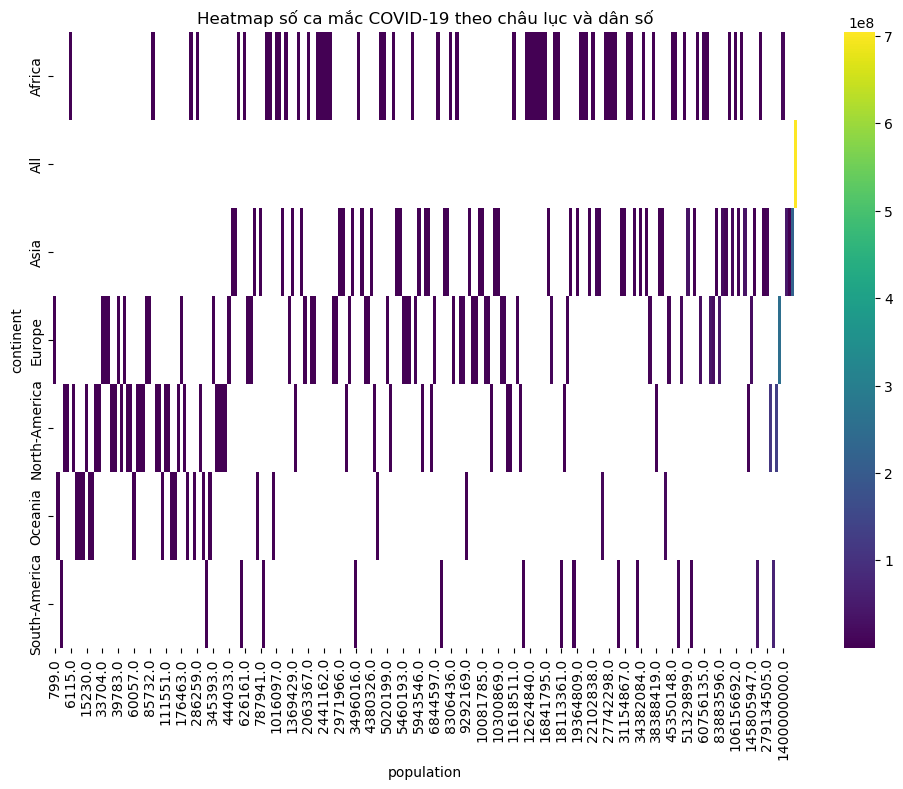

In [10]:
# Tạo ma trận dữ liệu 
pivot_table = pd.pivot_table(df, values='Cases', index='continent', columns='population')

# Vẽ heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(pivot_table, cmap='viridis')
plt.title('Heatmap số ca mắc COVID-19 theo châu lục và dân số')
plt.show()

In [11]:
#Thống kê các giá trị:
df.describe().T #Thống kê các giá trị trung bình, độ lệch chuẩn, min, max,... cho các cột số.

,count,mean,std,min,25%,50%,75%,max
population,235.0,1.015827e+08,6.249593e+08,799.0,582254.5,6684849.0,27826923.0,8.000000e+09
Cases,235.0,8.996852e+06,5.225233e+07,10.0,29125.5,234174.0,1658259.0,7.047539e+08
Recovered,235.0,8.693046e+06,5.014370e+07,2.0,25995.5,228805.0,1631805.0,6.756198e+08
Deaths,235.0,8.950715e+04,5.141976e+05,0.0,225.0,2349.0,17594.5,7.010681e+06
Tests,235.0,3.298829e+07,1.141036e+08,7850.0,420750.5,3078533.0,29673910.0,1.186852e+09


<Axes: >

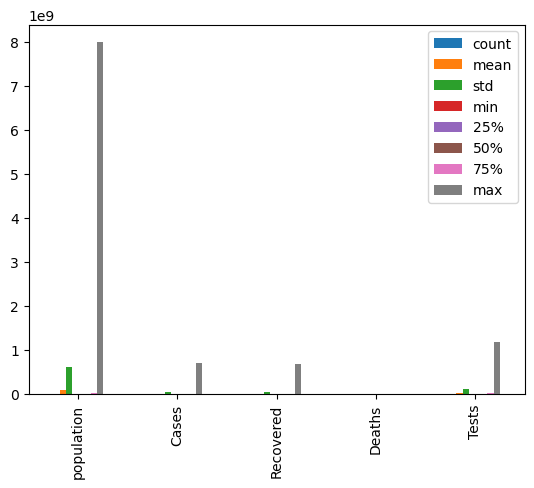

In [12]:
#Biểu diễn các giá trị được thống kê trên biểu đồ cột:
df.describe().T.plot(kind='bar')

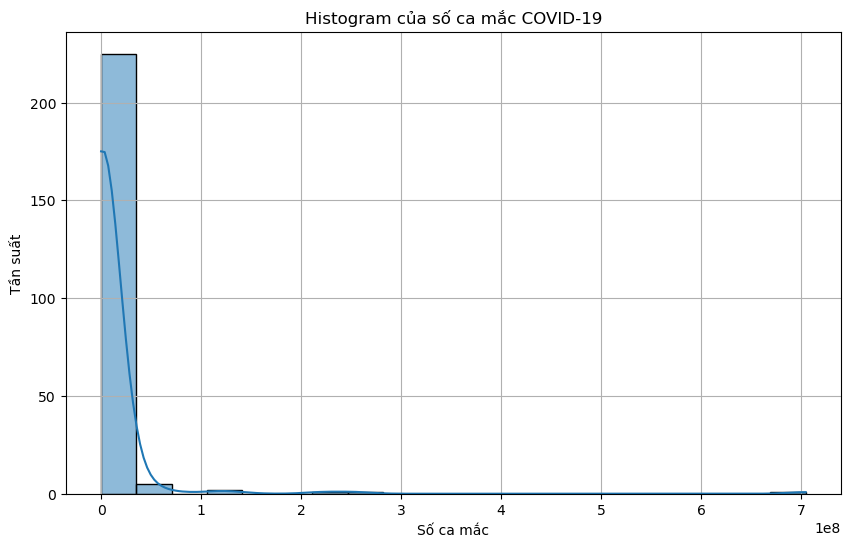

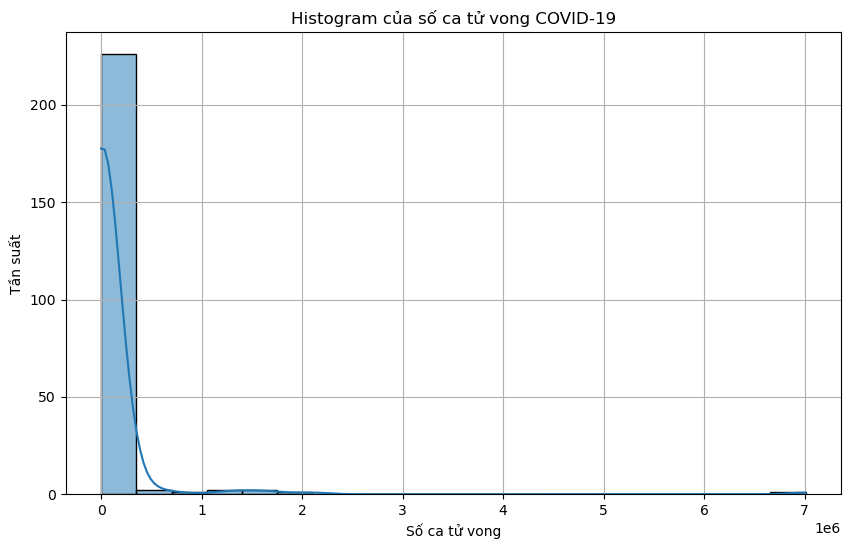

In [13]:
# Vẽ histogram cho cột 'Cases'
plt.figure(figsize=(10, 6))
sns.histplot(df['Cases'], bins=20, kde=True)
plt.title('Histogram của số ca mắc COVID-19')
plt.xlabel('Số ca mắc')
plt.ylabel('Tần suất')
plt.grid(True)
plt.show()

# Vẽ histogram cho cột 'Deaths'
plt.figure(figsize=(10, 6))
sns.histplot(df['Deaths'], bins=20, kde=True)
plt.title('Histogram của số ca tử vong COVID-19')
plt.xlabel('Số ca tử vong')
plt.ylabel('Tần suất')
plt.grid(True)
plt.show()

In [14]:
#Tính toán hệ số tương quan:
correlation_matrix = df[['population', 'Cases', 'Recovered', 'Deaths', 'Tests']].corr()
print(correlation_matrix)

            population     Cases  Recovered    Deaths     Tests
population    1.000000  0.906070   0.901682  0.883669  0.118141
Cases         0.906070  1.000000   0.999916  0.985561  0.158737
Recovered     0.901682  0.999916   1.000000  0.985570  0.162843
Deaths        0.883669  0.985561   0.985570  1.000000  0.168168
Tests         0.118141  0.158737   0.162843  0.168168  1.000000


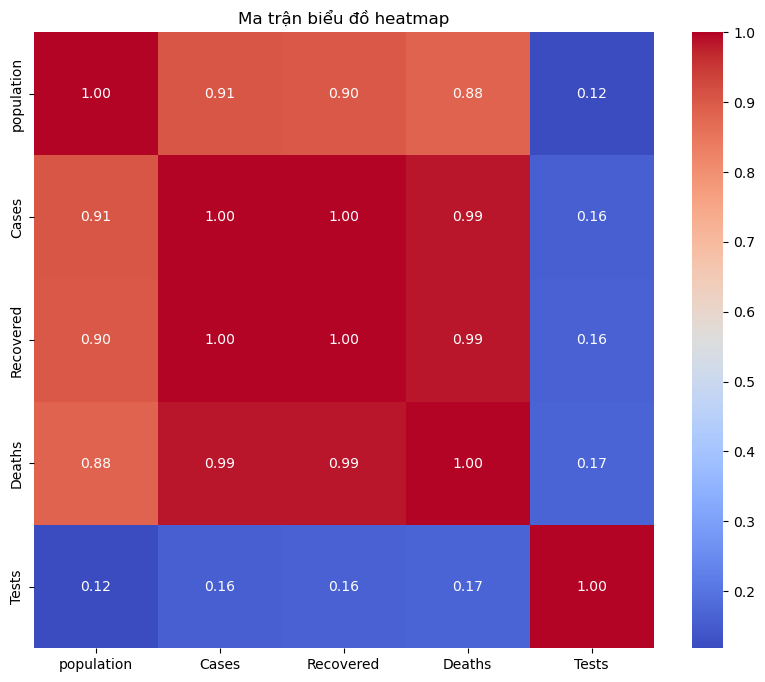

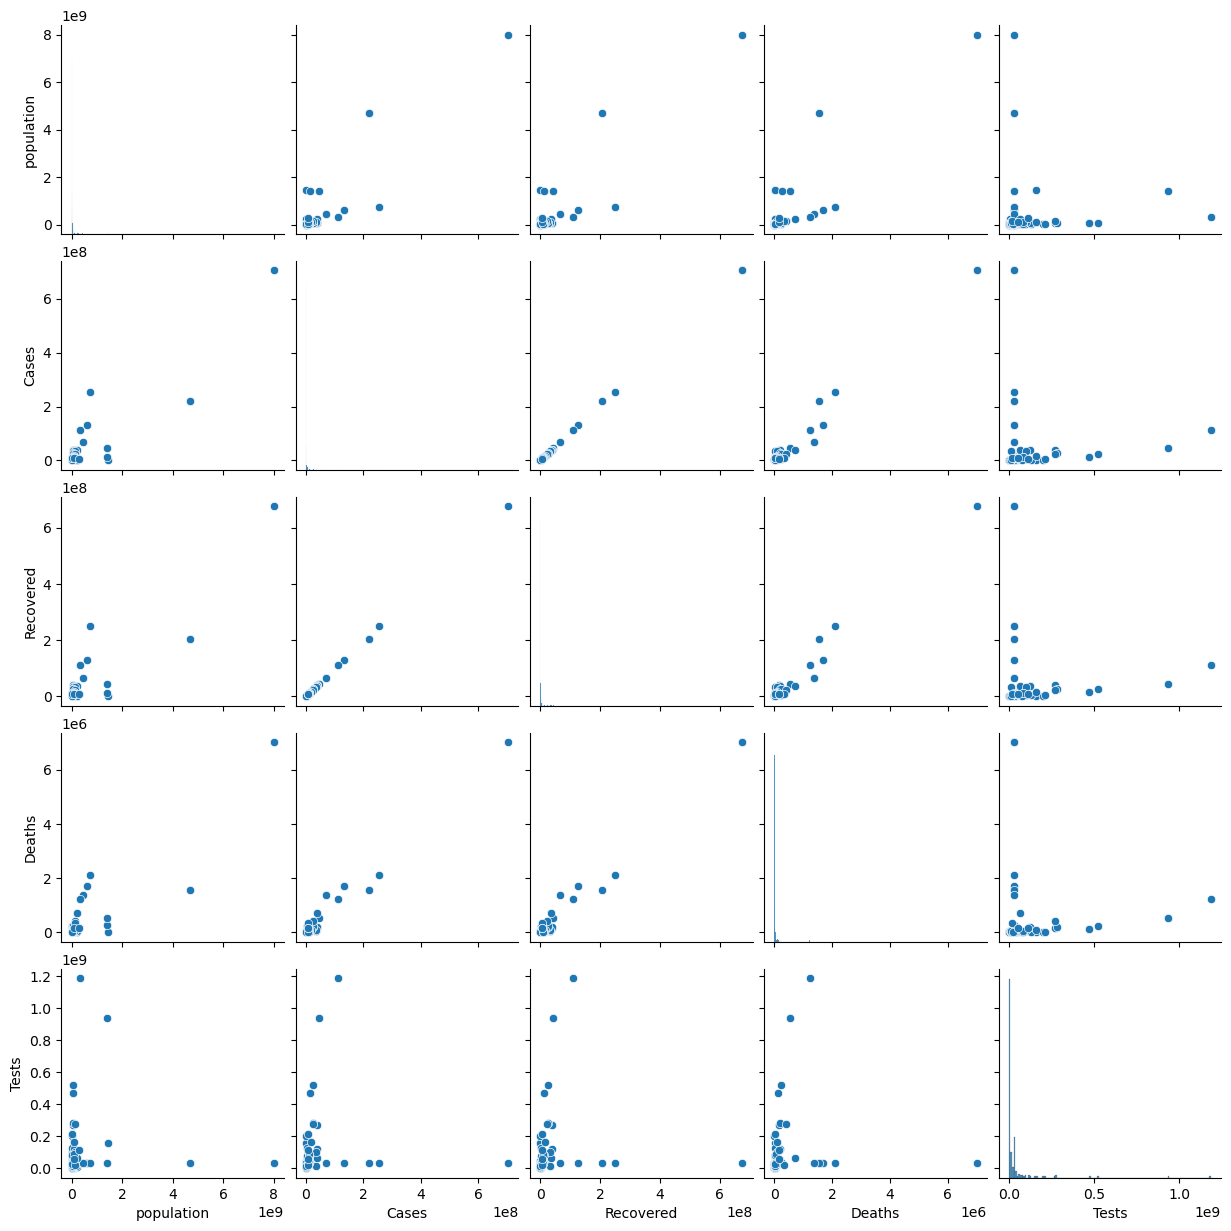

In [15]:
#Trực quan hóa mối quan hệ:
# Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Ma trận biểu đồ heatmap')
plt.show()

# Biểu đồ phân tán
sns.pairplot(df[['population', 'Cases', 'Recovered', 'Deaths', 'Tests']])
plt.show()

In [16]:
#tỉ lệ hồi phục theo từng quốc gia:
df['recovery_rate'] = df['Recovered'] / df['Cases']
print(df[['country', 'Cases', 'Recovered', 'recovery_rate']])

              country     Cases  Recovered  recovery_rate
0        Saint-Helena      2166        2.0       0.000923
1    Falkland-Islands      1930     1930.0       1.000000
2          Montserrat      1403     1376.0       0.980756
3        Vatican-City        29       29.0       1.000000
4      Western-Sahara        10        9.0       0.900000
..                ...       ...        ...            ...
230         Argentina  10128845  9997258.0       0.987009
231       Netherlands   8635786  8612599.0       0.997315
232            Mexico   7702809  6899865.0       0.895760
233              Iran   7627186  7480375.0       0.980752
234         Indonesia   6829221  6647104.0       0.973333

[235 rows x 4 columns]


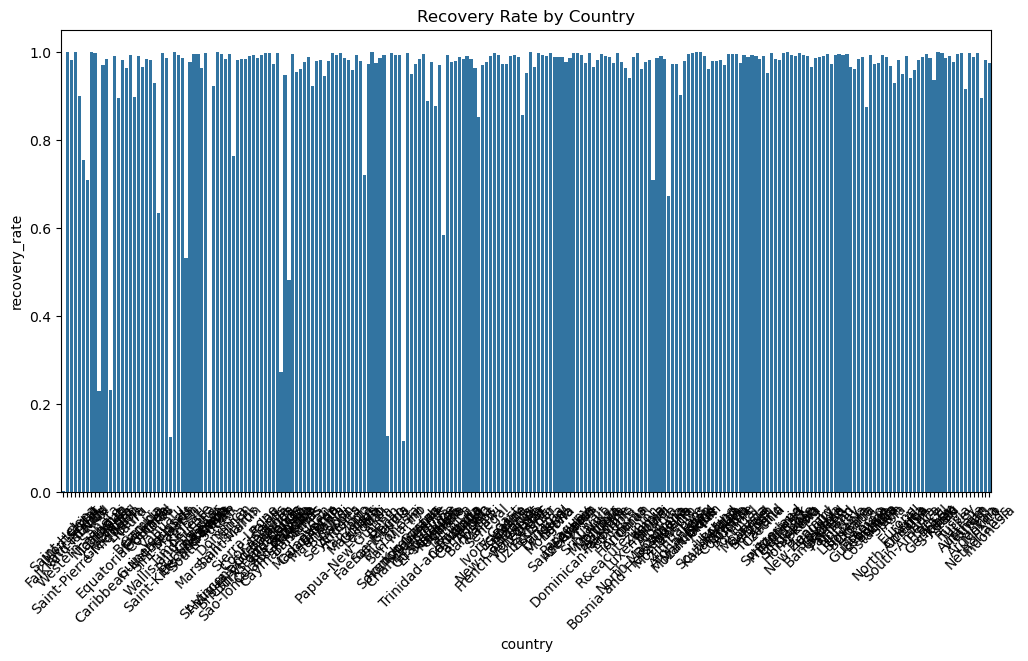

In [17]:
#Biểu đồ cột tỉ lệ hồi phục:
plt.figure(figsize=(12, 6))
sns.barplot(x='country', y='recovery_rate', data=df)
plt.title('Recovery Rate by Country')
plt.xticks(rotation=45)
plt.show()

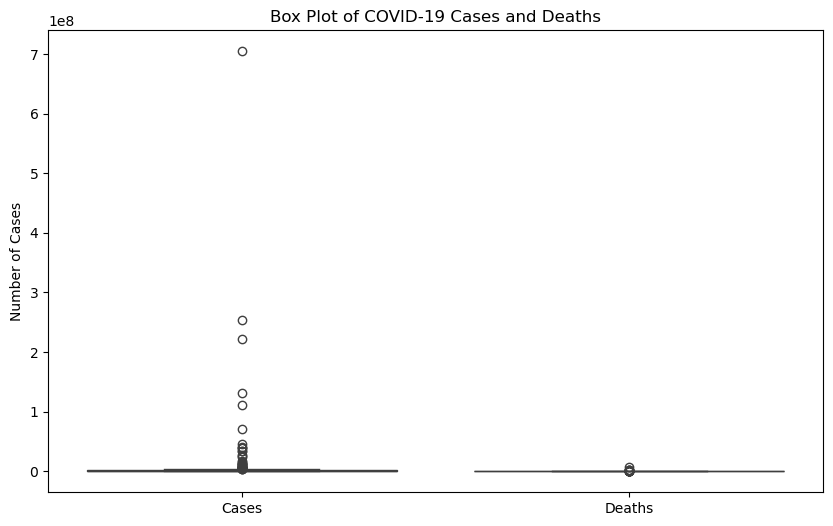

In [18]:
#Vẽ biểu đồ BoxPlot:
# Lấy dữ liệu từ cột 'Cases' và 'Deaths'
cases = df['Cases']
deaths = df['Deaths']
# Tạo DataFrame kết hợp
data = pd.DataFrame({'Cases': cases, 'Deaths': deaths})

# Tạo BoxPlot
plt.figure(figsize=(10, 6))
sns.boxplot(data=data)
plt.title('Box Plot of COVID-19 Cases and Deaths')
plt.ylabel('Number of Cases')
plt.show()

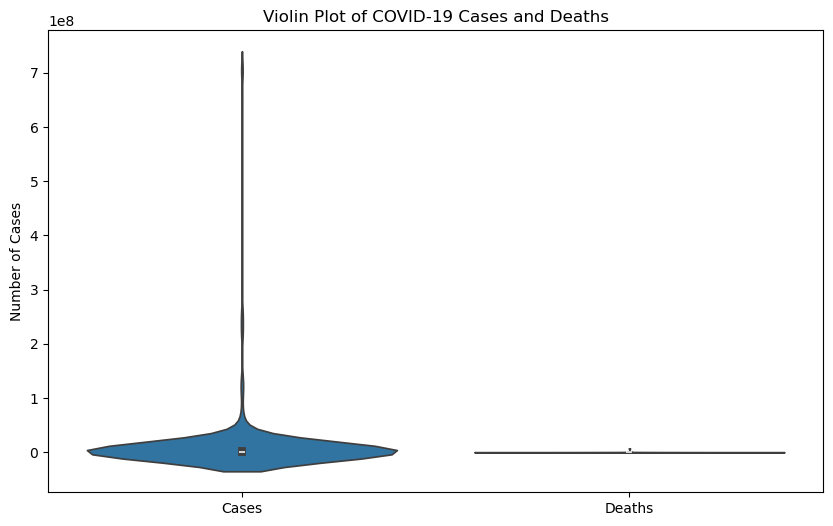

In [19]:
# Vẽ biểu đồ ViolinPlot
plt.figure(figsize=(10, 6))
sns.violinplot(data=data)
plt.title('Violin Plot of COVID-19 Cases and Deaths')
plt.ylabel('Number of Cases')
plt.show()

In [20]:
# Các cột số cần tính z-score
numeric_columns = ['population', 'Cases', 'Recovered', 'Deaths', 'Tests']

# Tính z-score cho từng cột số
for col in numeric_columns:
    z_col_name = f'Z-{col}'
    df[z_col_name] = stats.zscore(df[col])

z_columns = ['Z-population', 'Z-Cases', 'Z-Recovered', 'Z-Deaths', 'Z-Tests']

for col in z_columns:
    if col in df.columns: #kiểm tra xem cột z-score có tồn tại không.
        df[col] = df[col].round(3)  # Làm tròn đến 3 chữ số thập phân

df

,country,continent,population,day,time,Cases,Recovered,Deaths,Tests,recovery_rate,Z-population,Z-Cases,Z-Recovered,Z-Deaths,Z-Tests
0,Saint-Helena,Africa,6115.0,2024-06-30,2024-06-30T16:15:16+00:00,2166,2.0,2164.0,3.298829e+07,0.000923,-0.163,-0.173,-0.174,-0.170,-0.000
1,Falkland-Islands,South-America,3539.0,2024-06-30,2024-06-30T16:15:16+00:00,1930,1930.0,0.0,8.632000e+03,1.000000,-0.163,-0.173,-0.174,-0.174,-0.290
2,Montserrat,North-America,4965.0,2024-06-30,2024-06-30T16:15:16+00:00,1403,1376.0,8.0,1.776200e+04,0.980756,-0.163,-0.173,-0.174,-0.174,-0.290
3,Vatican-City,Europe,799.0,2024-06-30,2024-06-30T16:15:16+00:00,29,29.0,0.0,3.298829e+07,1.000000,-0.163,-0.173,-0.174,-0.174,-0.000
4,Western-Sahara,Africa,626161.0,2024-06-30,2024-06-30T16:15:16+00:00,10,9.0,1.0,3.298829e+07,0.900000,-0.162,-0.173,-0.174,-0.174,-0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
230,Argentina,South-America,46010234.0,2024-06-30,2024-06-30T16:15:10+00:00,10128845,9997258.0,130841.0,3.571607e+07,0.987009,-0.089,0.022,0.026,0.081,0.024
231,Netherlands,Europe,17211447.0,2024-06-30,2024-06-30T16:15:10+00:00,8635786,8612599.0,22992.0,2.598444e+07,0.997315,-0.135,-0.007,-0.002,-0.130,-0.062
232,Mexico,North-America,131562772.0,2024-06-30,2024-06-30T16:15:10+00:00,7702809,6899865.0,334958.0,2.001381e+07,0.895760,0.048,-0.025,-0.036,0.478,-0.114
233,Iran,Asia,86022837.0,2024-06-30,2024-06-30T16:15:10+00:00,7627186,7480375.0,146811.0,5.732027e+07,0.980752,-0.025,-0.026,-0.024,0.112,0.214


In [21]:
#Tỷ lệ ca nhiễm trên dân số:
df['cases_per_population'] = df['Cases'] / df['population']
print(df[['country', 'population', 'Cases', 'cases_per_population']])

              country   population     Cases  cases_per_population
0        Saint-Helena       6115.0      2166              0.354211
1    Falkland-Islands       3539.0      1930              0.545352
2          Montserrat       4965.0      1403              0.282578
3        Vatican-City        799.0        29              0.036295
4      Western-Sahara     626161.0        10              0.000016
..                ...          ...       ...                   ...
230         Argentina   46010234.0  10128845              0.220143
231       Netherlands   17211447.0   8635786              0.501747
232            Mexico  131562772.0   7702809              0.058549
233              Iran   86022837.0   7627186              0.088665
234         Indonesia  279134505.0   6829221              0.024466

[235 rows x 4 columns]


In [22]:
#Tỷ lệ xét nghiệm trên dân số:
df['tests_per_population'] = df['Tests'] / df['population']
print(df[['country', 'population', 'Tests', 'tests_per_population']])

              country   population         Tests  tests_per_population
0        Saint-Helena       6115.0  3.298829e+07           5394.650508
1    Falkland-Islands       3539.0  8.632000e+03              2.439107
2          Montserrat       4965.0  1.776200e+04              3.577442
3        Vatican-City        799.0  3.298829e+07          41286.968529
4      Western-Sahara     626161.0  3.298829e+07             52.683396
..                ...          ...           ...                   ...
230         Argentina   46010234.0  3.571607e+07              0.776264
231       Netherlands   17211447.0  2.598444e+07              1.509718
232            Mexico  131562772.0  2.001381e+07              0.152124
233              Iran   86022837.0  5.732027e+07              0.666338
234         Indonesia  279134505.0  1.141589e+08              0.408975

[235 rows x 4 columns]


In [23]:
#Tính tỉ lệ tử vong trên số ca nhiễm:
df['Mortality Rate'] = (df['Deaths'] / df['Cases'])

print(df[["Deaths", "Cases", "Mortality Rate"]])

       Deaths     Cases  Mortality Rate
0      2164.0      2166        0.999077
1         0.0      1930        0.000000
2         8.0      1403        0.005702
3         0.0        29        0.000000
4         1.0        10        0.100000
..        ...       ...             ...
230  130841.0  10128845        0.012918
231   22992.0   8635786        0.002662
232  334958.0   7702809        0.043485
233  146811.0   7627186        0.019248
234  162063.0   6829221        0.023731

[235 rows x 3 columns]


In [24]:
# Sắp xếp dữ liệu cột Mortality Rate
df_sorted = df.sort_values(by='Mortality Rate')

# Hiển thị 10 quốc gia đầu tiên có tỉ lệ tử vong thấp nhất
top_10 = df_sorted[['country', 'Mortality Rate']].tail(10)
print("10 quốc gia có tỷ lệ tử vong cao nhất:")
print(top_10)

# Hiển thị 10 quốc gia có tỷ lệ tử vong cao nhất
top_10_highest = df_sorted[['country', 'Mortality Rate']].head(10)
print("10 quốc gia có tỷ lệ tử vong thấp nhất:")
print(top_10_highest)

10 quốc gia có tỷ lệ tử vong cao nhất:
                    country  Mortality Rate
143  Bosnia-and-Herzegovina        0.040603
232                  Mexico        0.043485
116                   Egypt        0.047697
178                    Peru        0.048585
57                  Somalia        0.049791
66                    Syria        0.054812
63                    Sudan        0.078852
4            Western-Sahara        0.100000
43                    Yemen        0.180745
0              Saint-Helena        0.999077
10 quốc gia có tỷ lệ tử vong thấp nhất:
                   country  Mortality Rate
3             Vatican-City        0.000000
1         Falkland-Islands        0.000000
161                   DPRK        0.000016
17                   Nauru        0.000185
48            Cook-Islands        0.000278
65                  Bhutan        0.000335
7                   Tuvalu        0.000340
6    Saint-Pierre-Miquelon        0.000579
149                 Brunei        0.000655
183    

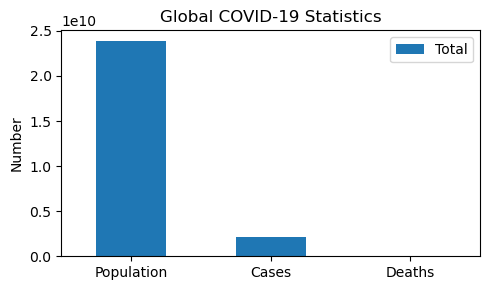

In [25]:
# Tính tổng dân số, số ca mắc và tử vong
total_population = df['population'].sum()
total_cases = df['Cases'].sum()
total_deaths = df['Deaths'].sum()

# Tạo DataFrame mới chứa dữ liệu tổng
total_data = pd.DataFrame({
    'Total': [total_population, total_cases, total_deaths]
}, index=['Population', 'Cases', 'Deaths'])

# Vẽ biểu đồ cột
total_data.plot(kind='bar', figsize=(5, 3))#figsize : thiết lập kích thước biểu đồ rộng 10 cao 6

# Đặt tiêu đề và nhãn
plt.title('Global COVID-19 Statistics')
plt.ylabel('Number')
plt.xticks(rotation=0)

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

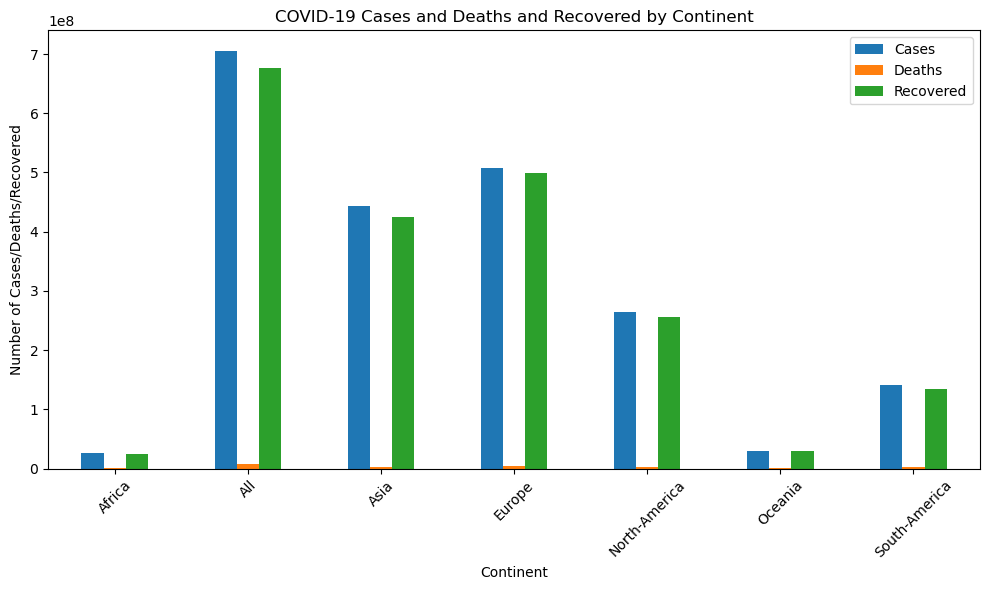

In [26]:
# Nhóm dữ liệu theo châu lục và tính tổng số ca mắc và tử vong và đã hết bệnh
continent_data = df.groupby('continent')[['Cases', 'Deaths', 'Recovered']].sum()

# Vẽ biểu đồ cột nhóm theo châu lục:
continent_data.plot(kind='bar', figsize=(10, 6))

# Đặt tiêu đề và nhãn
plt.title('COVID-19 Cases and Deaths and Recovered by Continent')
plt.xlabel('Continent')
plt.ylabel('Number of Cases/Deaths/Recovered')

# Hiển thị biểu đồ
plt.xticks(rotation=45)#Xoay nhãn trục x
plt.tight_layout()
plt.show()

In [27]:
df.to_csv("Analytic_Covid19.csv", index = False)

                                             |          | [  0%]   00:00 -> (? left)

Report Describing covid 19 dataset.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.



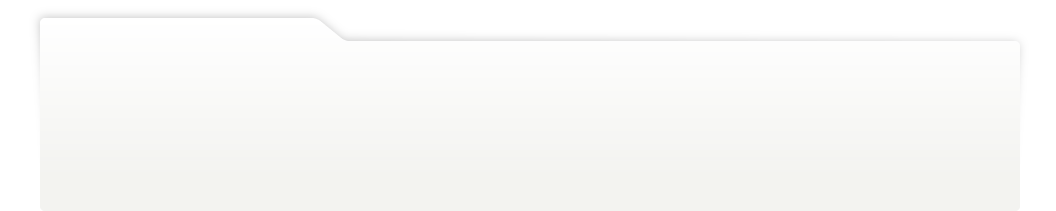
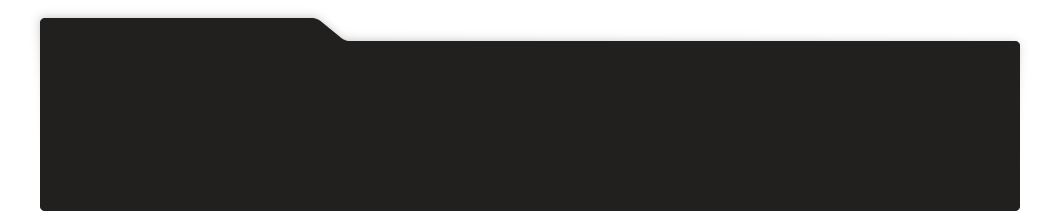
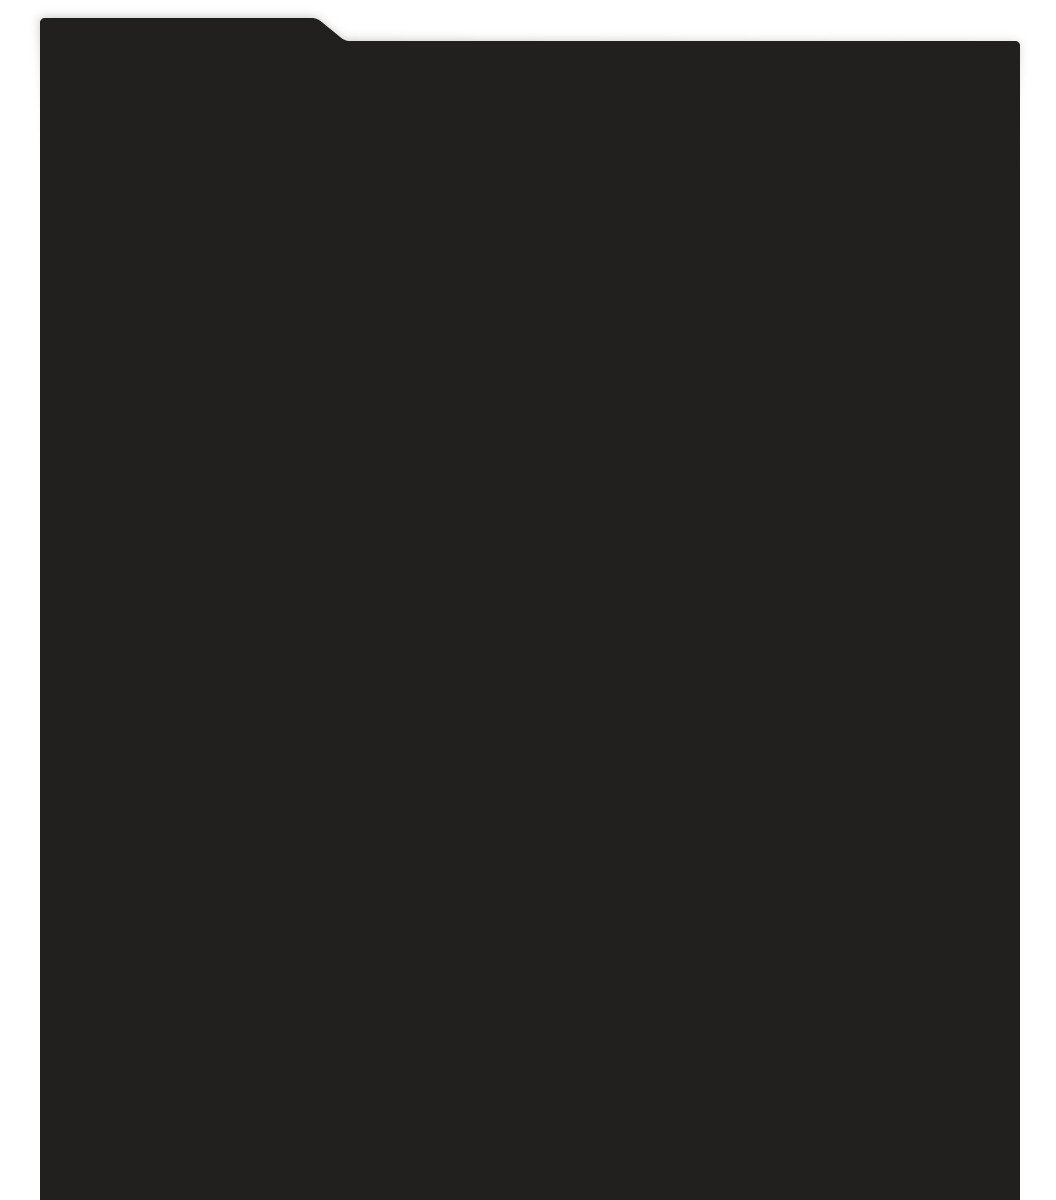
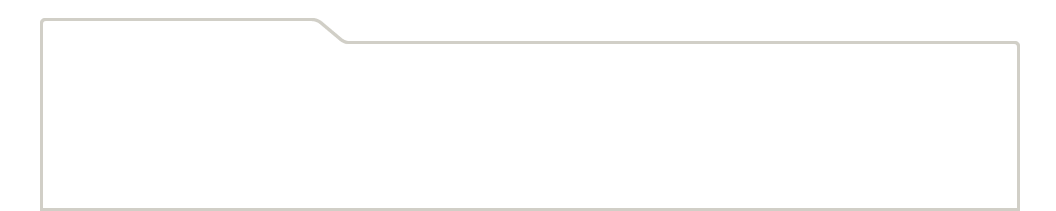
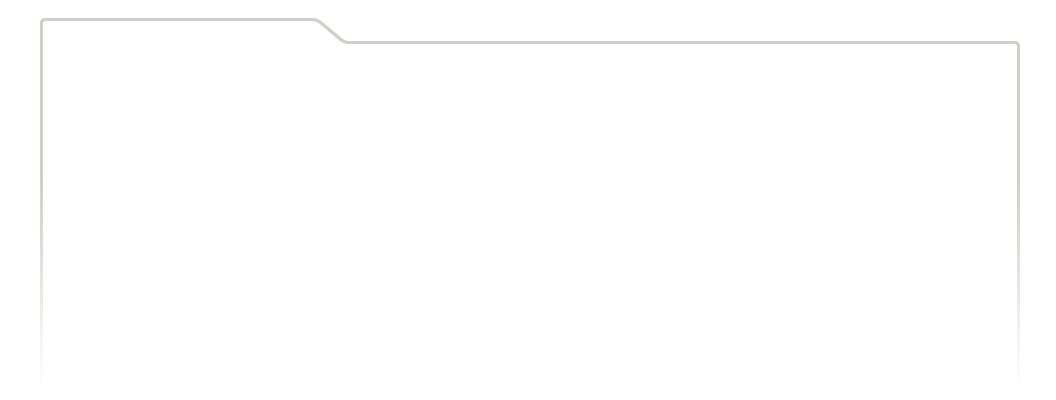
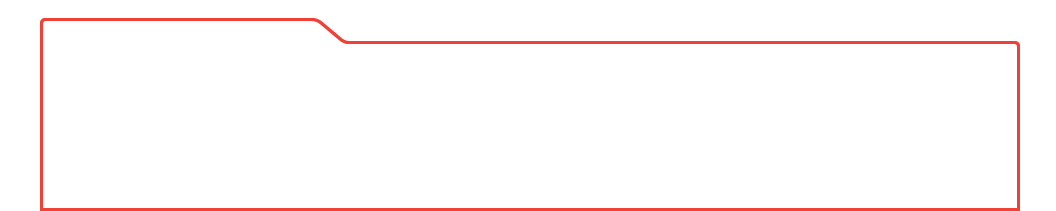
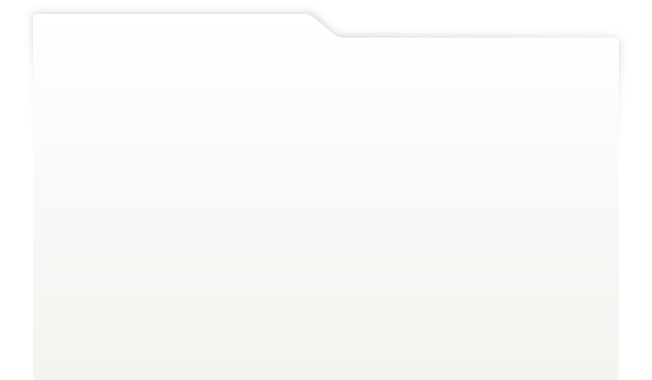
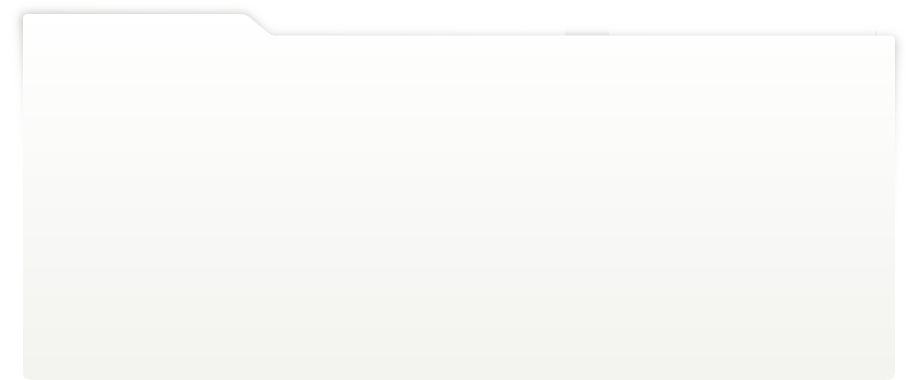
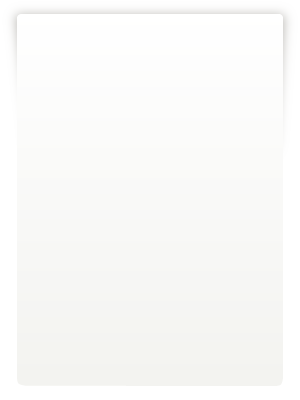
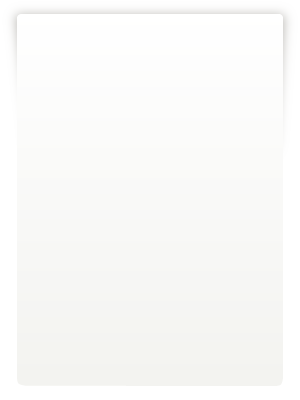
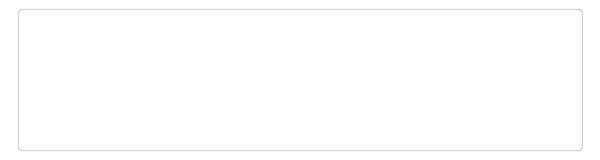
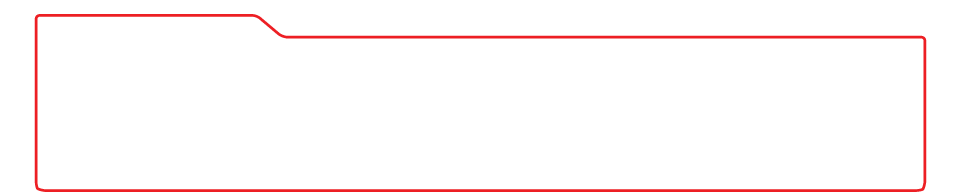
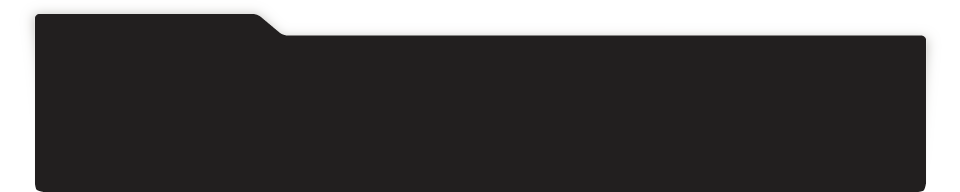
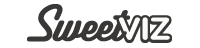
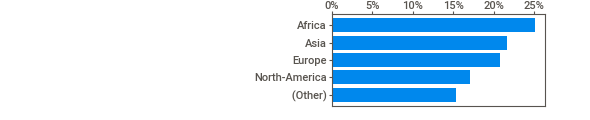
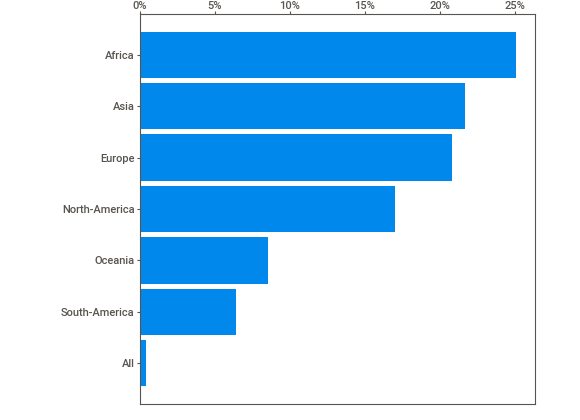
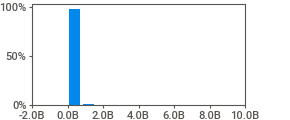
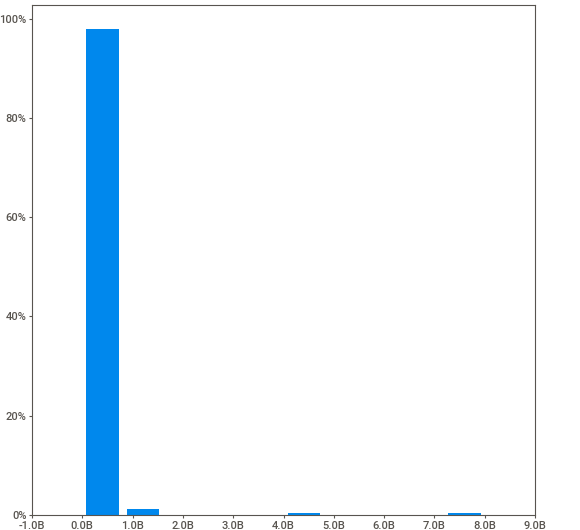
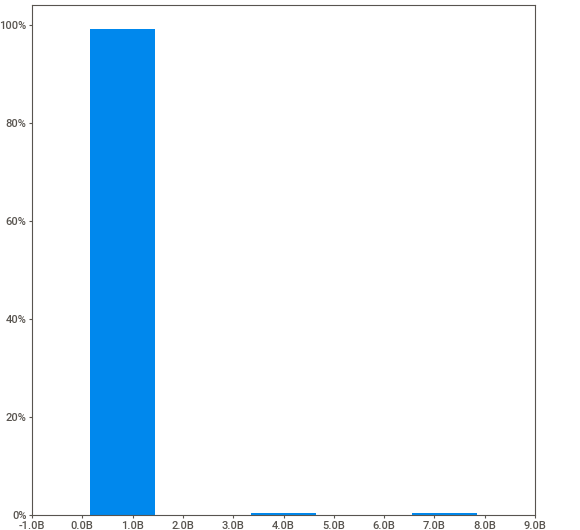
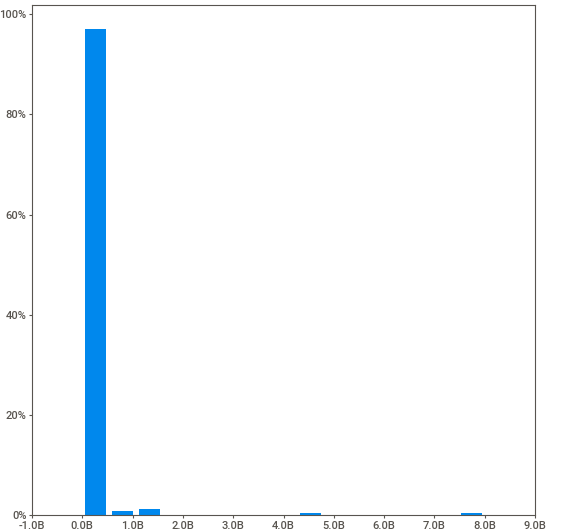
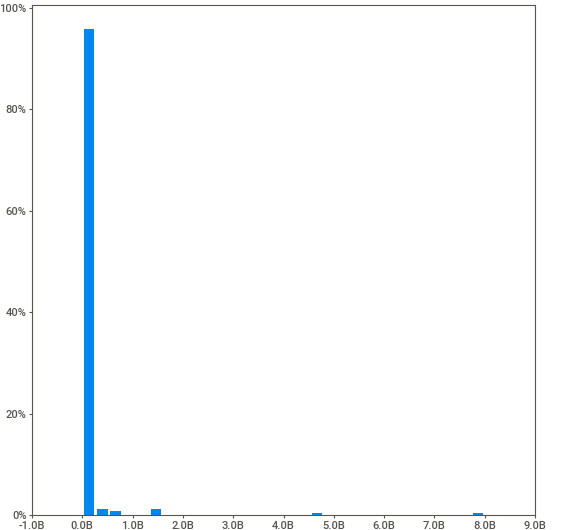
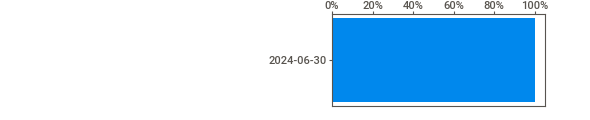
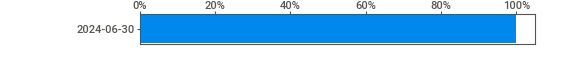
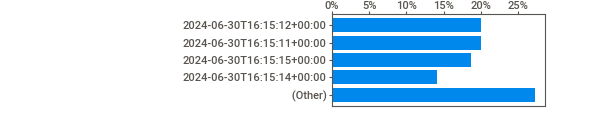
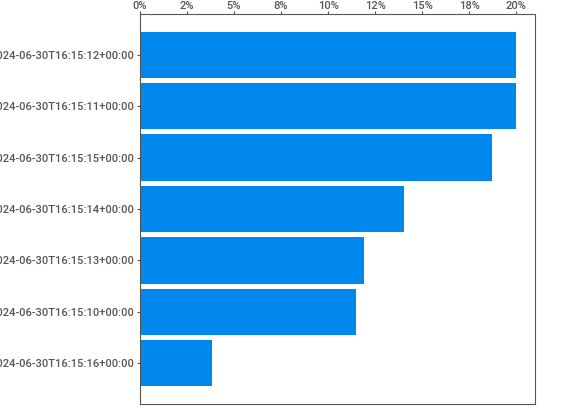
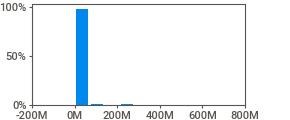
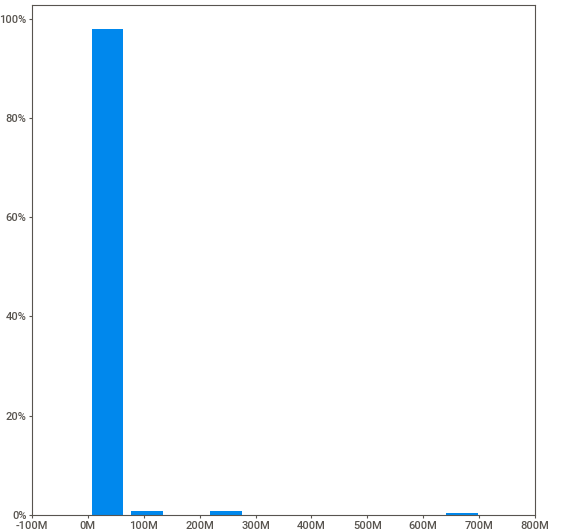
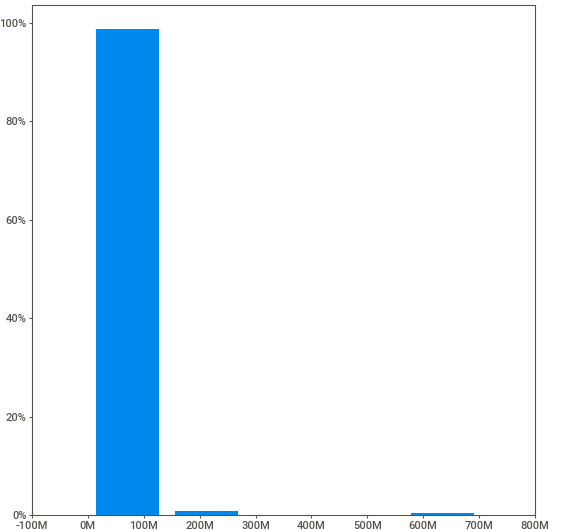
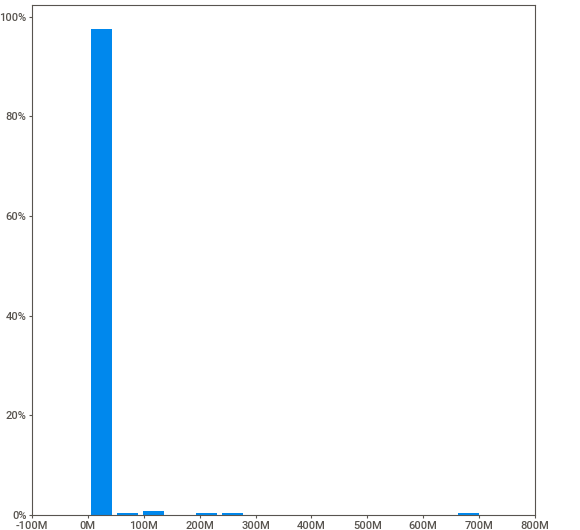
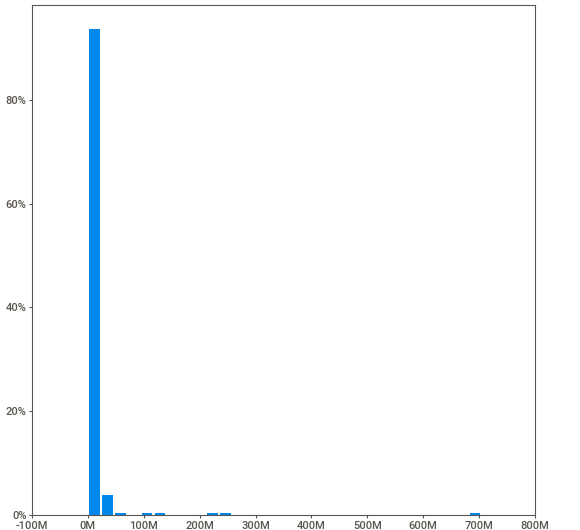
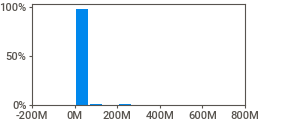
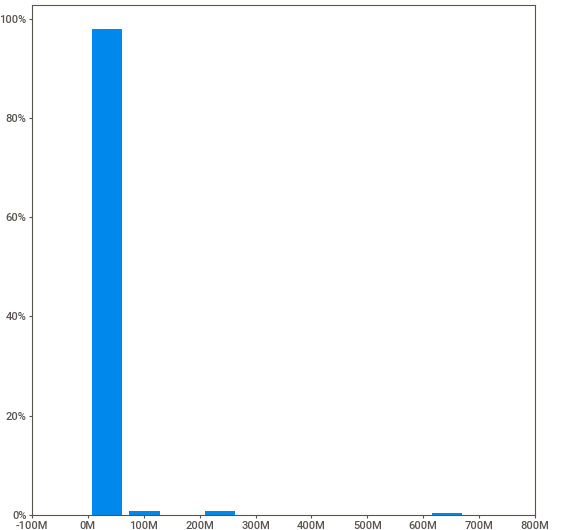
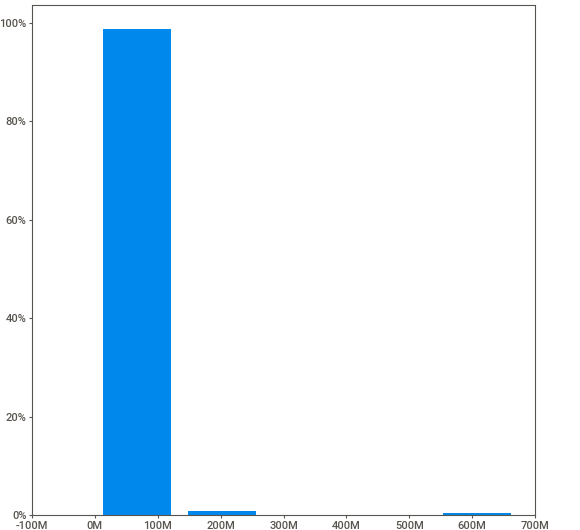
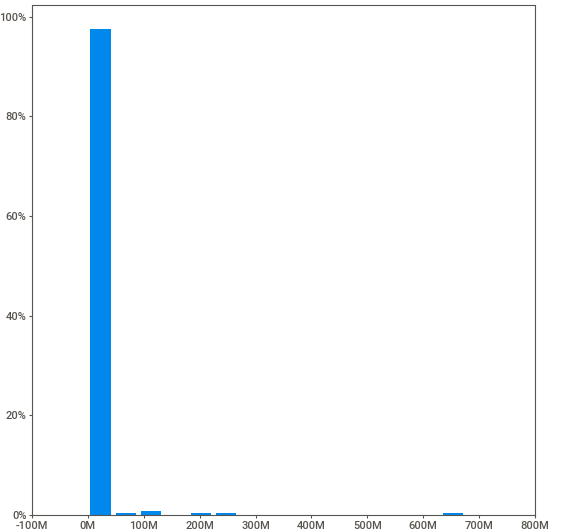
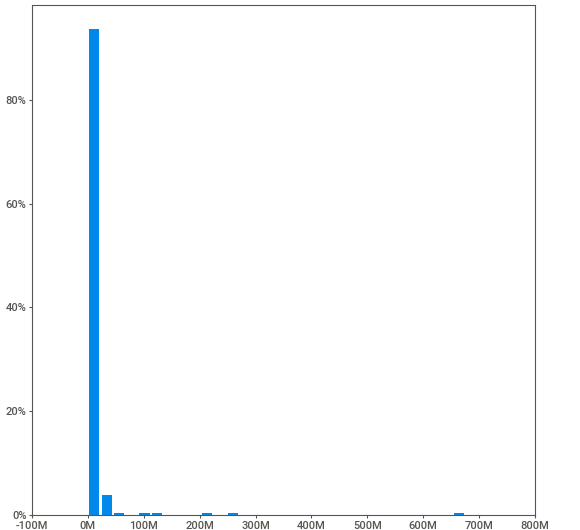
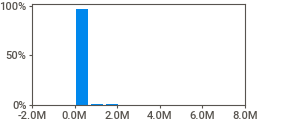
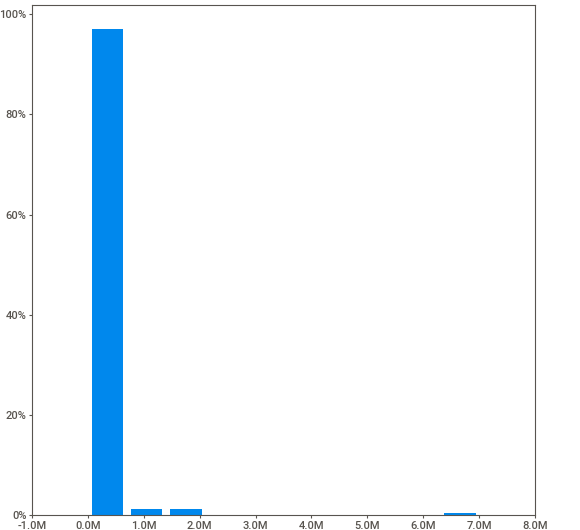
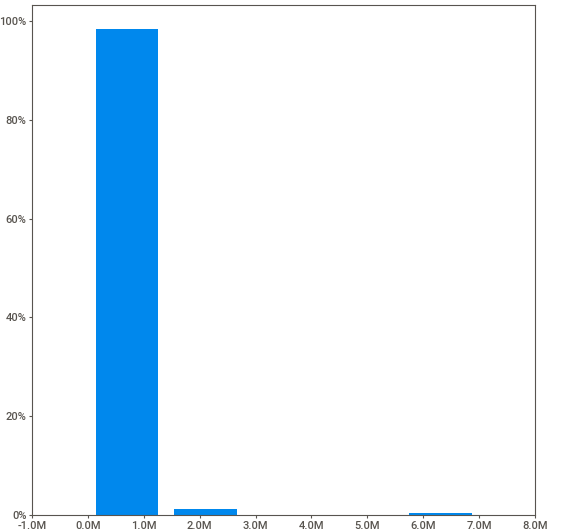
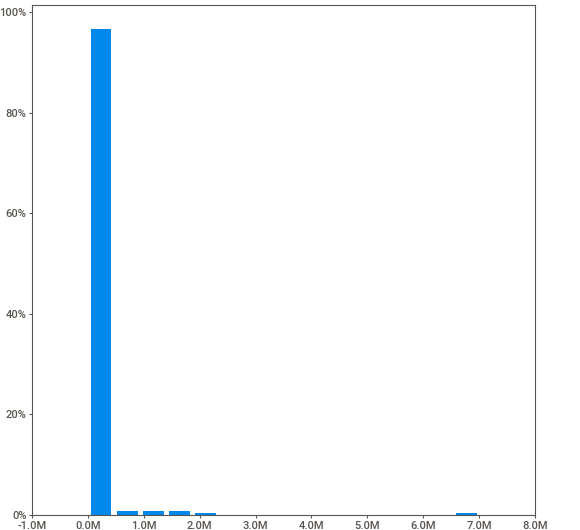
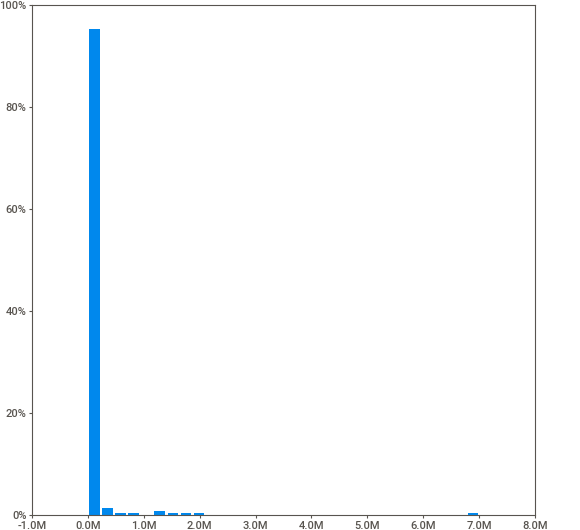
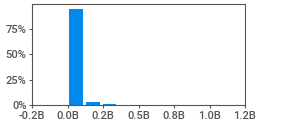
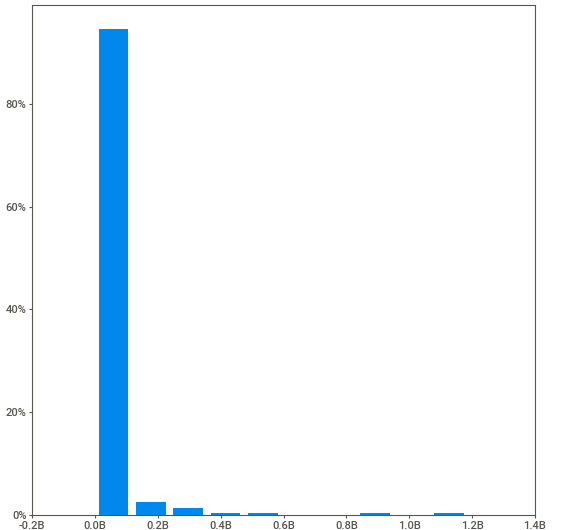
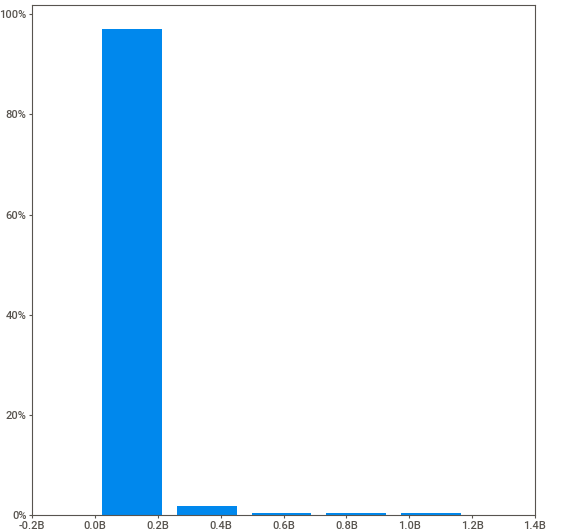
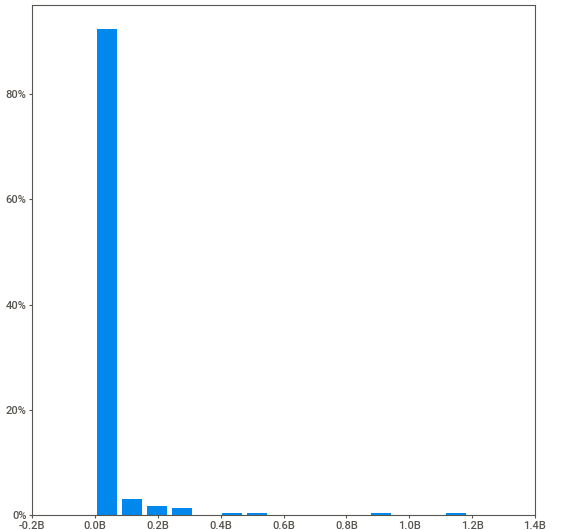
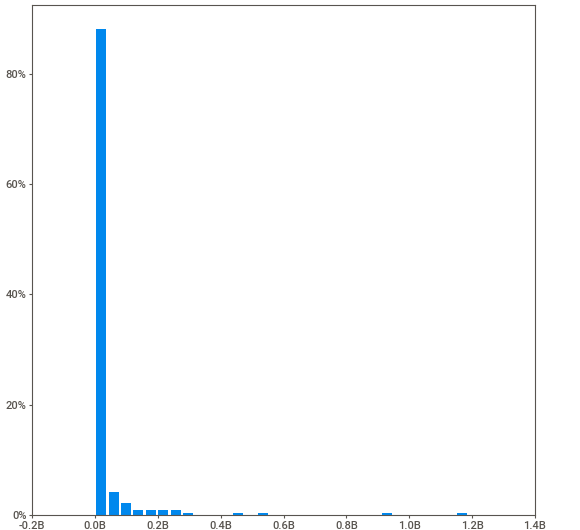
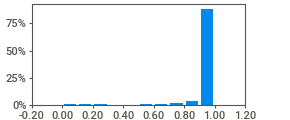
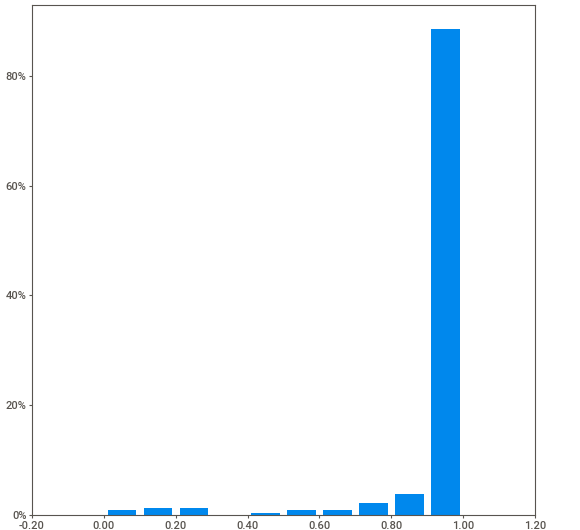
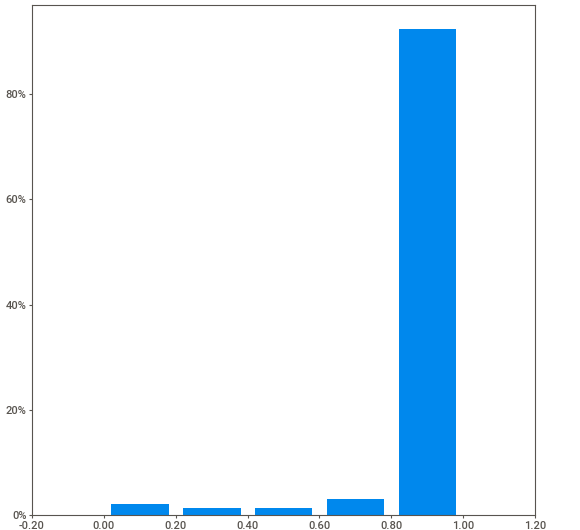
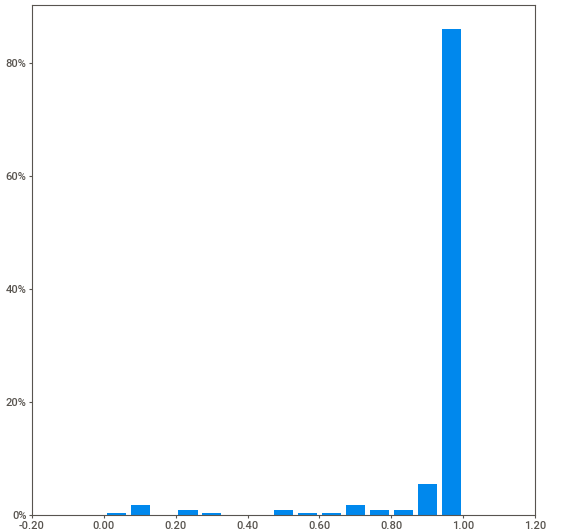
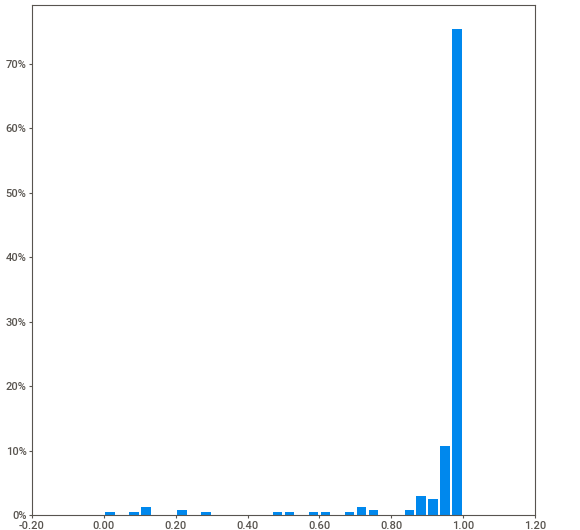
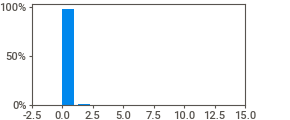
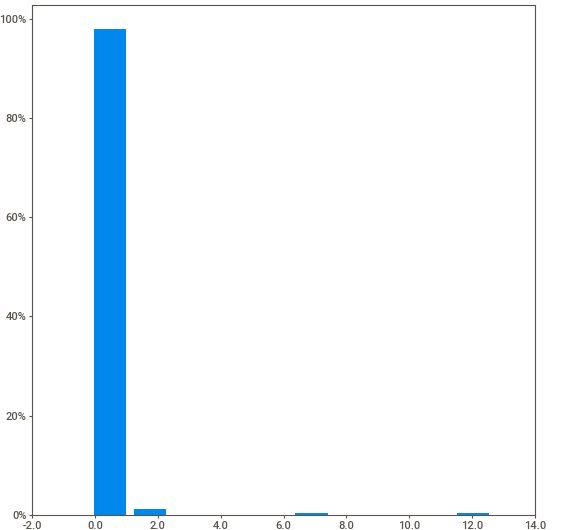
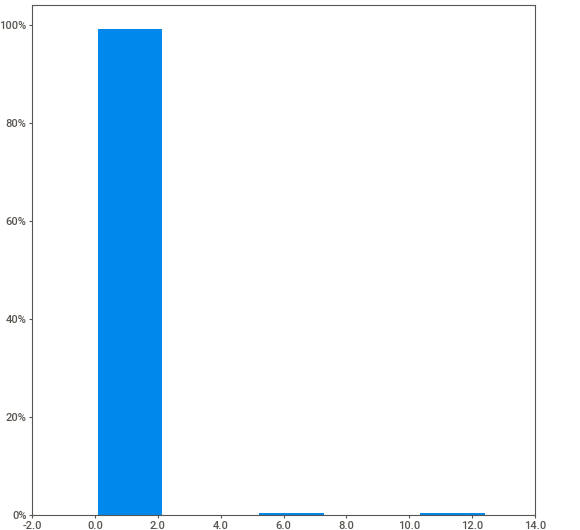
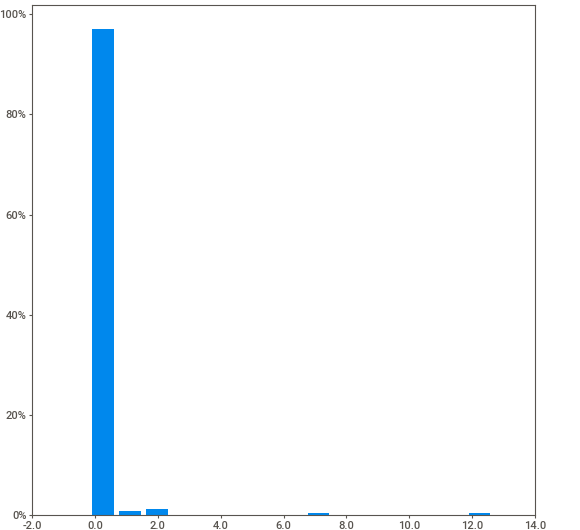
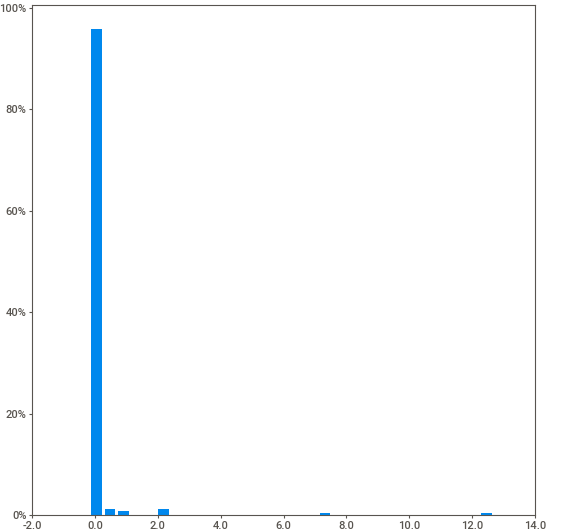
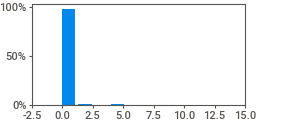
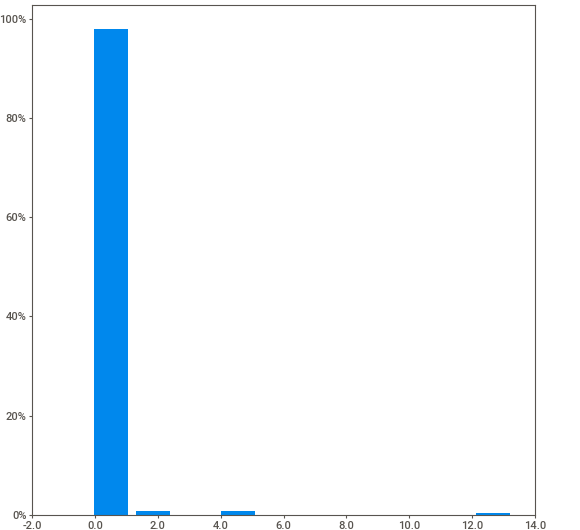
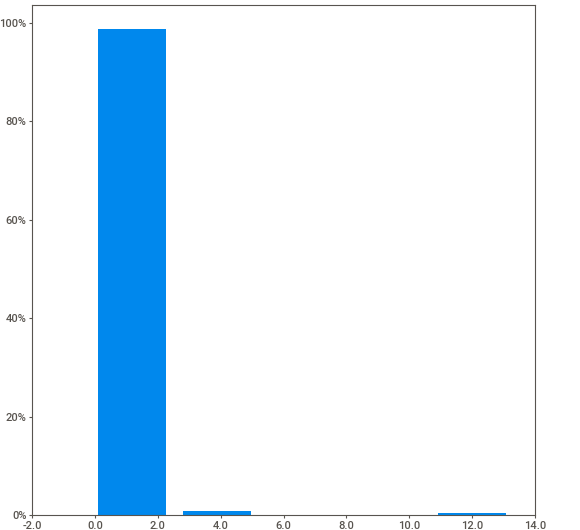
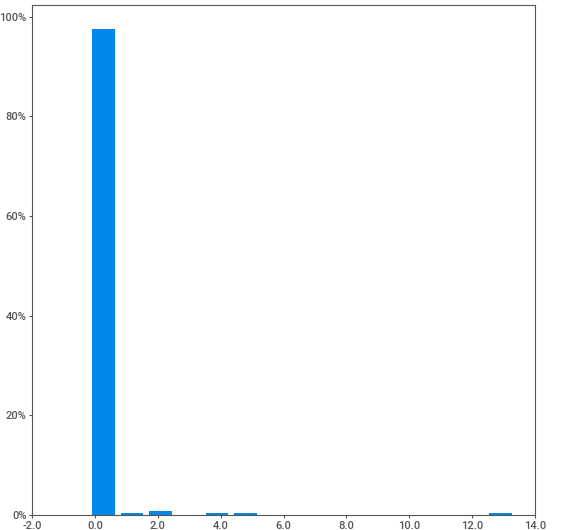
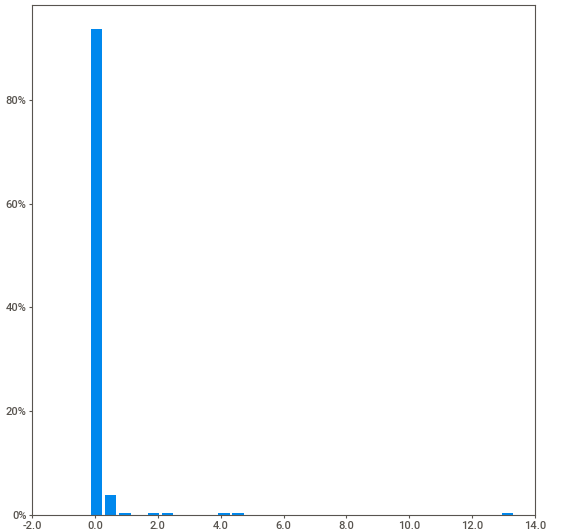
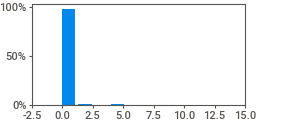
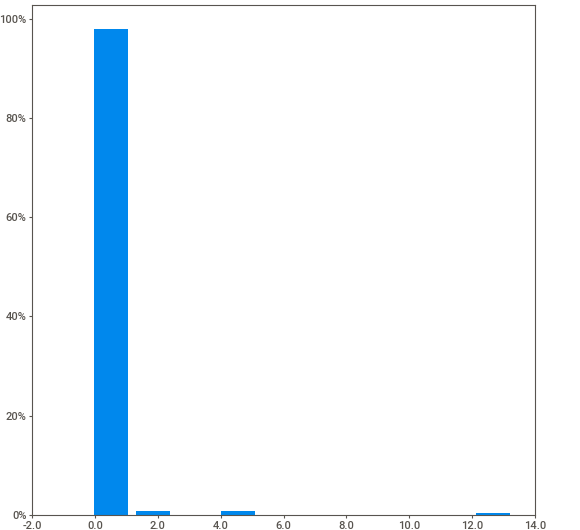
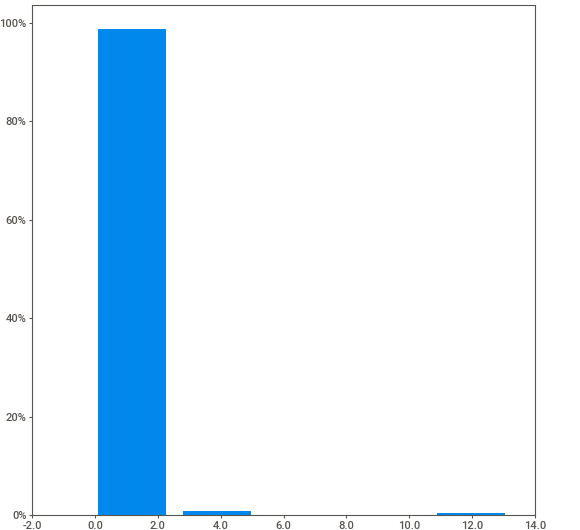
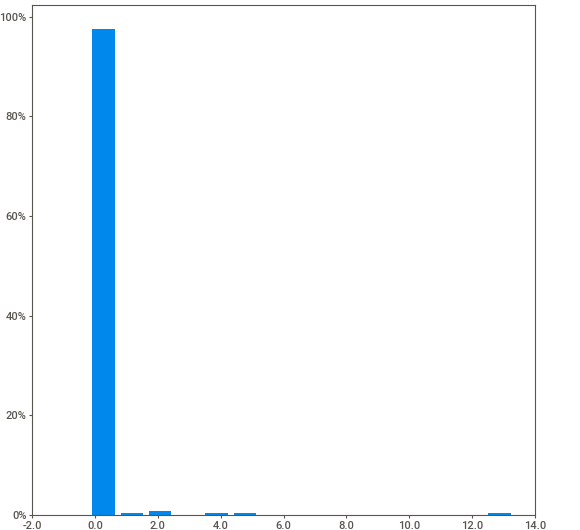
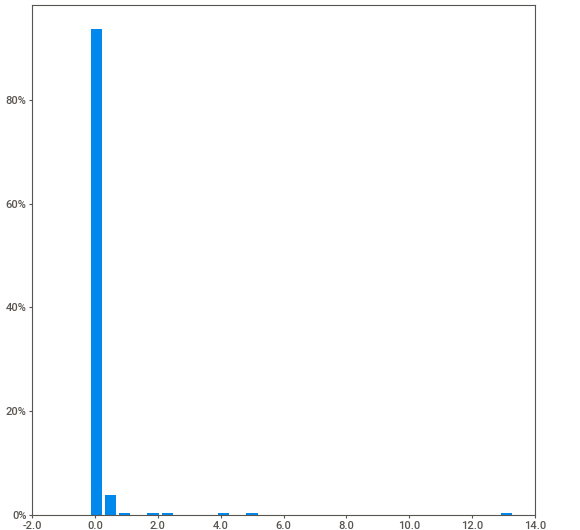
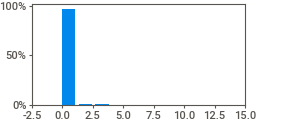
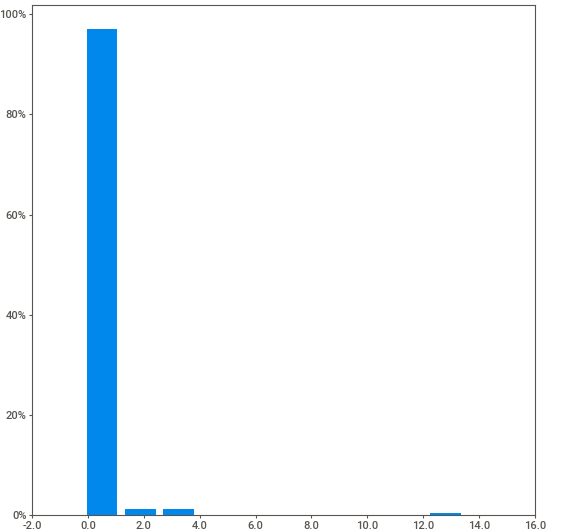
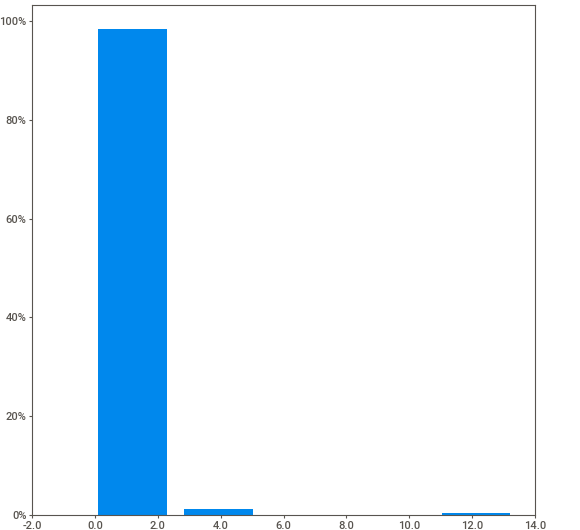
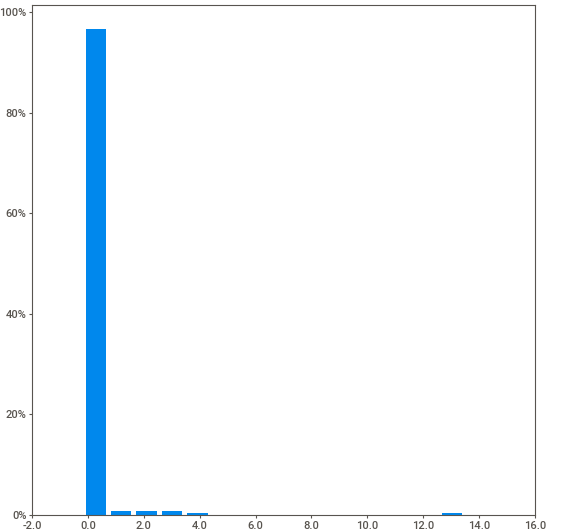
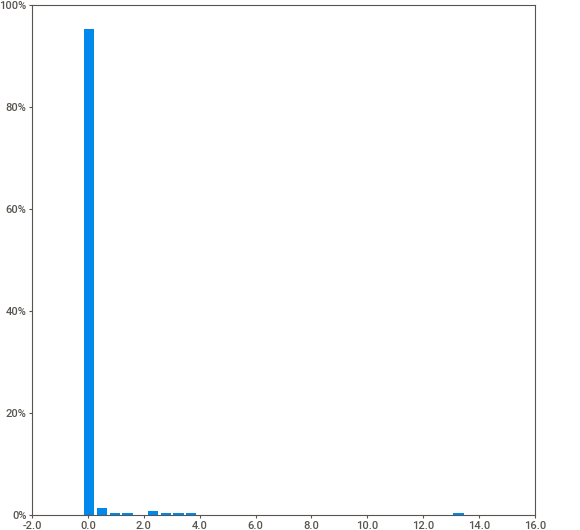
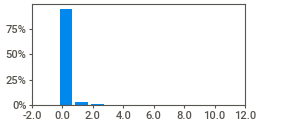
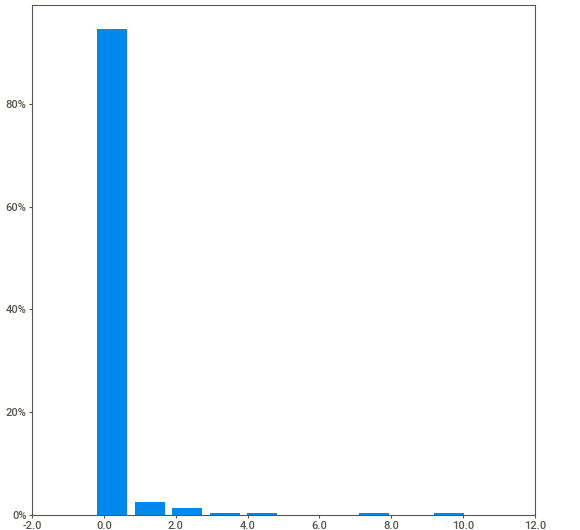
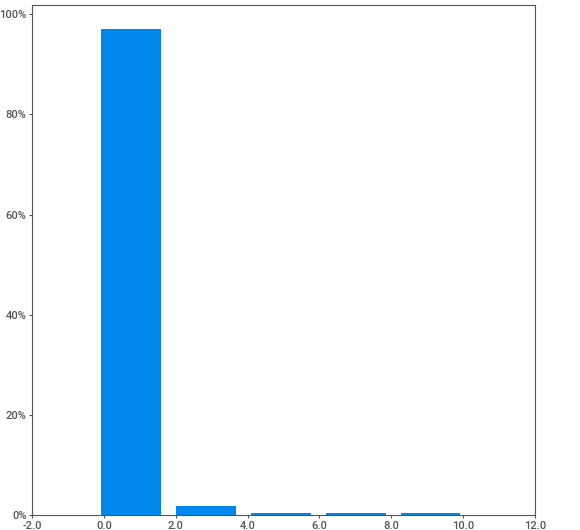
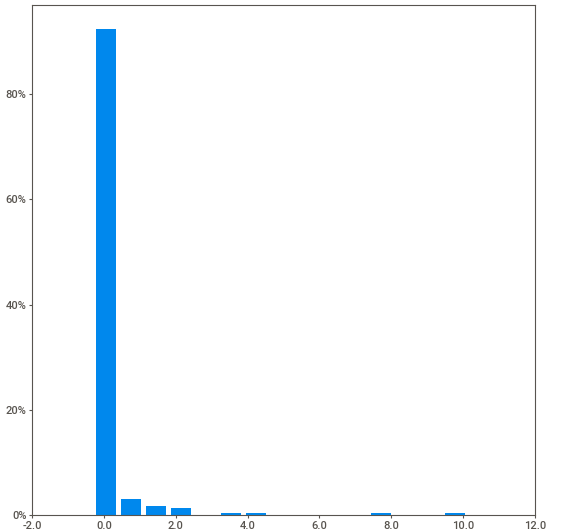
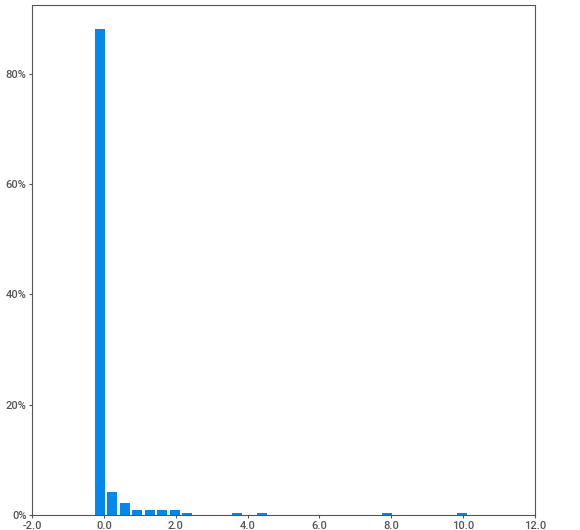
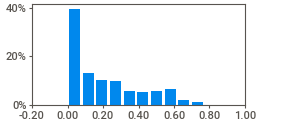
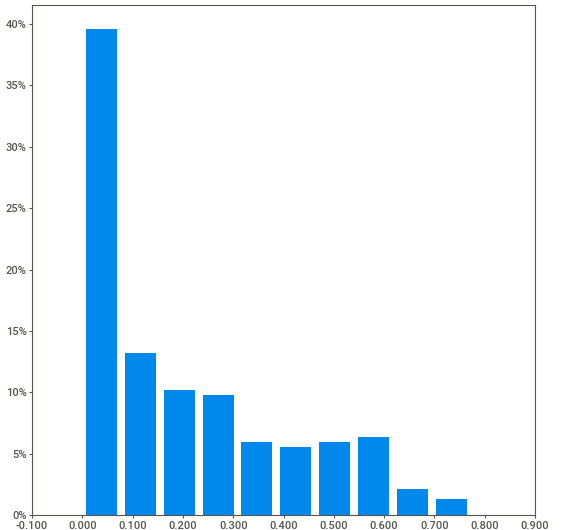
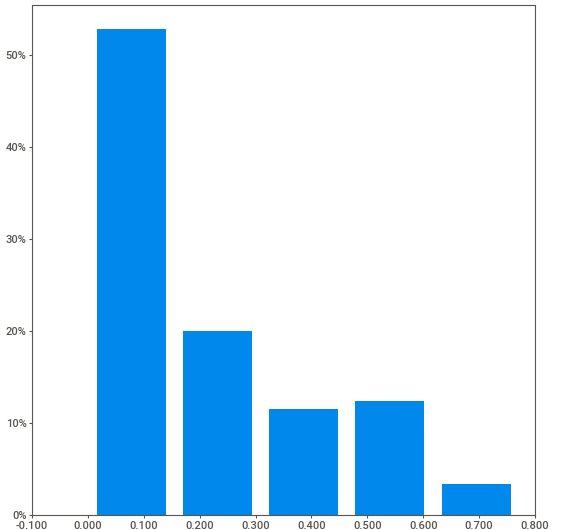
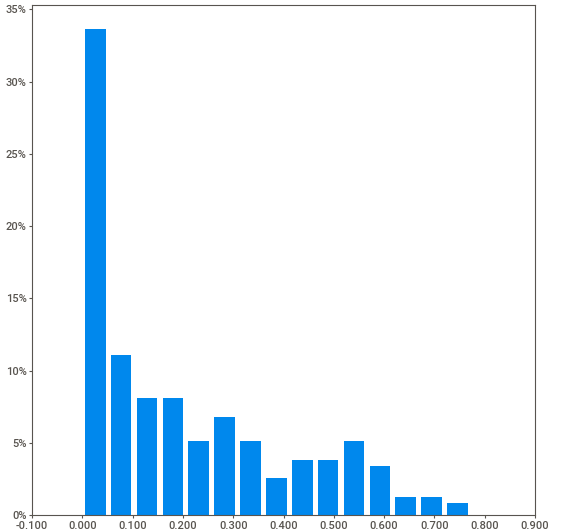
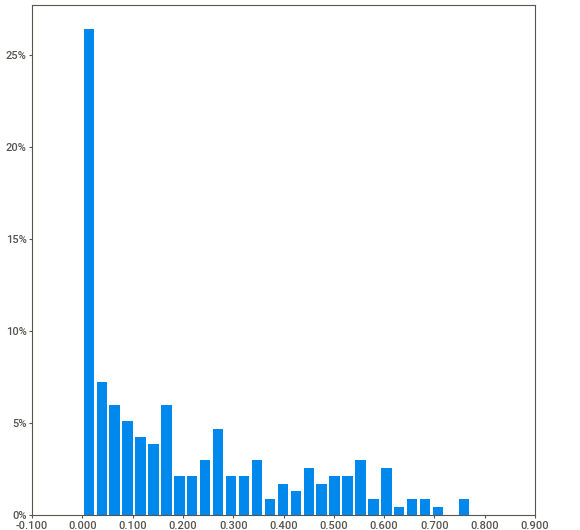
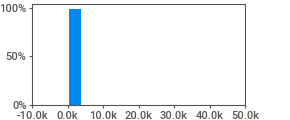
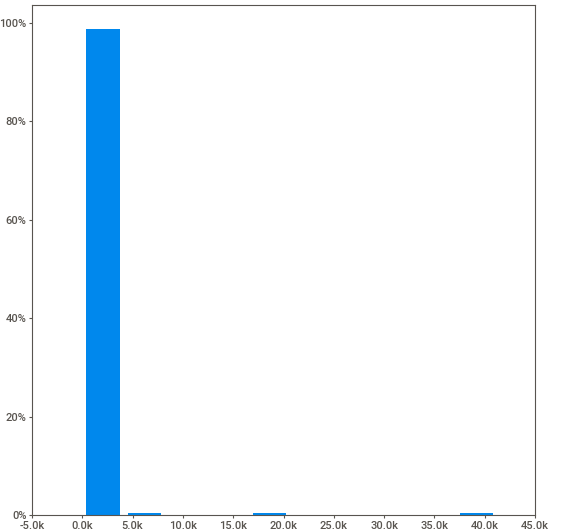
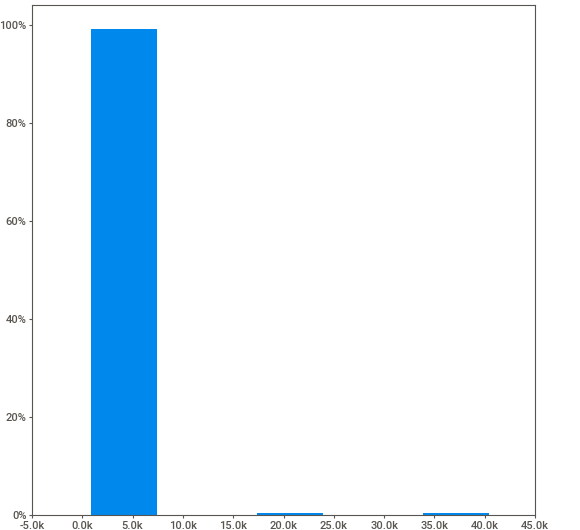
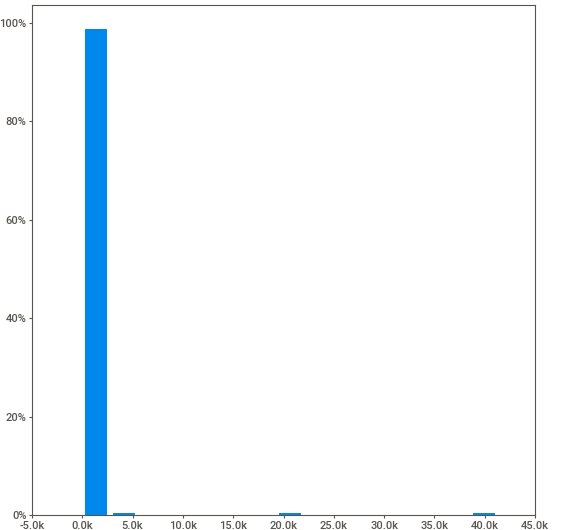
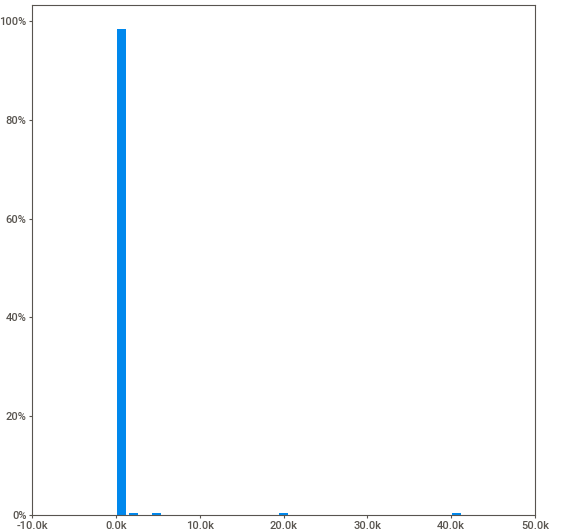
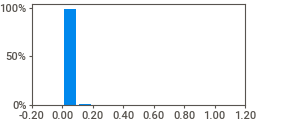
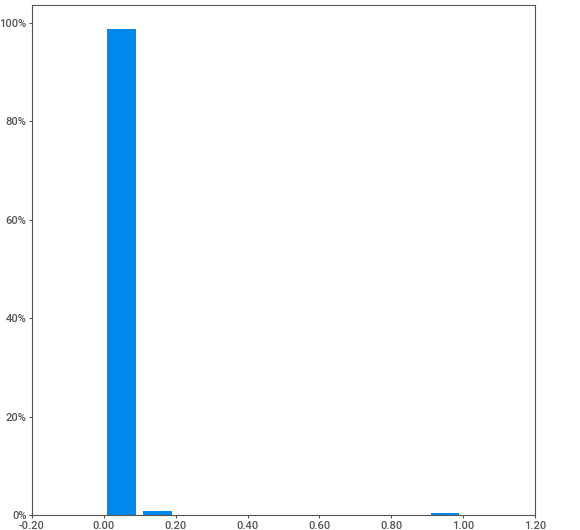
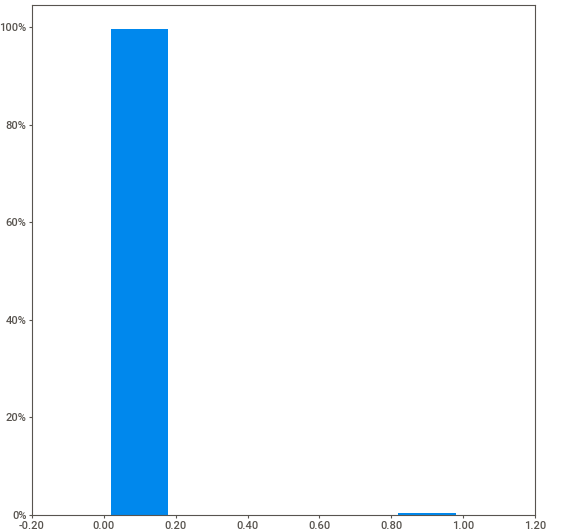
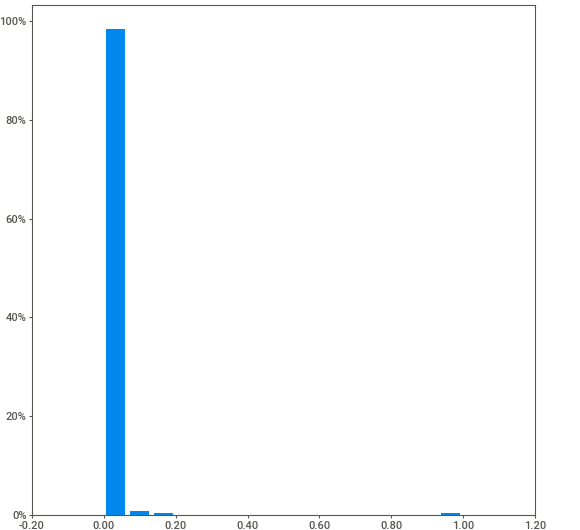
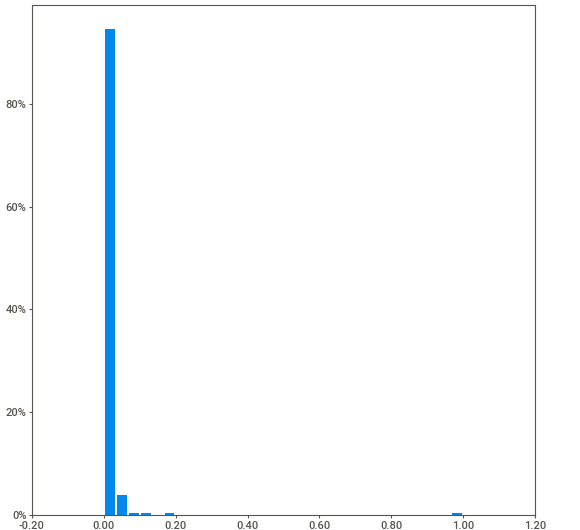
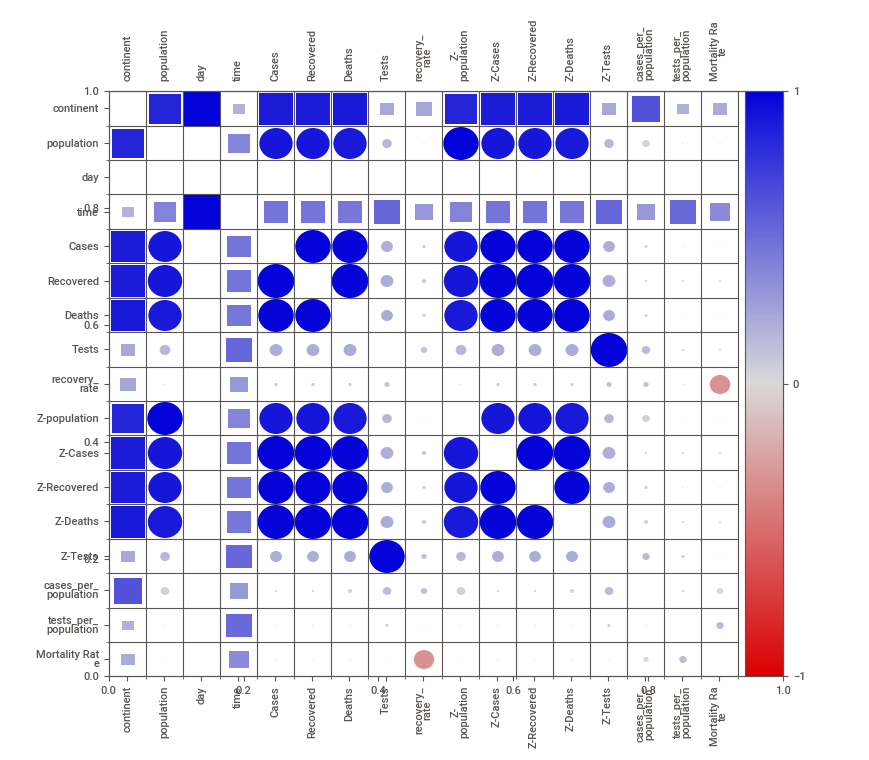
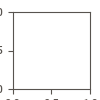

In [28]:
import sweetviz as sv

#Tải Dataset đã được chuẩn hoá:
df = pd.read_csv('Analytic_Covid19.csv')

# Tạo báo cáo:
report = sv.analyze(df)

# Lưu báo cáo vào một tập tin HTML:
report.show_html("Describing covid 19 dataset.html")

# Hiển thị báo cáo trên Jupyter Notebook:
report.show_notebook()